# **⚕️Health Analysis of Central Asian Countries**


- - -
## ***1. Introduction***

**Objective**:

This project aims to assess the healthcare systems of Central Asian countries at the macro level from 2000 to 2021.


**Data**:
*   The data were extracted from the [Global Health Observatory (GHO)](https://www.who.int/data/gho/data/indicators) data repository of the World Health Organization (WHO) and the [World Bank Open Data](https://data.worldbank.org/indicator) online platform.
*   Panel data analysis covering the period from 2000 to 2021
*   Sample size: 110 observations (22 per each country)

**Variables/Parameters**:

WHO data:
- [Life expectancy at birth (years)](https://www.who.int/data/gho/data/indicators/indicator-details/GHO/life-expectancy-at-birth-(years))
- [Current health expenditure (CHE) per capita in US$](https://www.who.int/data/gho/data/indicators/indicator-details/GHO/current-health-expenditure-(che)-per-capita-in-us-dollar)
- [Current health expenditure (CHE) as percentage of gross domestic product (GDP) (%)](https://www.who.int/data/gho/data/indicators/indicator-details/GHO/current-health-expenditure-(che)-as-percentage-of-gross-domestic-product-(gdp)-(-))
- [Beds, hospital beds (per 10 000 population)](https://www.who.int/data/gho/data/indicators/indicator-details/GHO/hospital-beds-(per-10-000-population))
- [Medical doctors (per 10 000 population)](https://www.who.int/data/gho/data/indicators/indicator-details/GHO/medical-doctors-(per-10-000-population))
- [Diphtheria tetanus toxoid and pertussis (DTP3) immunization coverage among 1-year-olds (%)](https://www.who.int/data/gho/data/indicators/indicator-details/GHO/diphtheria-tetanus-toxoid-and-pertussis-(dtp3)-immunization-coverage-among-1-year-olds-(-))
- [Child deaths in infants, infant mortality rate (between birth and 11 months per 1000 live births)](https://www.who.int/data/gho/data/indicators/indicator-details/GHO/infant-mortality-rate-(probability-of-dying-between-birth-and-age-1-per-1000-live-births))
- [Child deaths: under-five mortality rate (per 1000 live births)](https://www.who.int/data/gho/data/indicators/indicator-details/GHO/under-five-mortality-rate-(probability-of-dying-by-age-5-per-1000-live-births))
- [Maternal mortality ratio (per 100 000 live births)](https://www.who.int/data/gho/data/indicators/indicator-details/GHO/maternal-mortality-ratio-(per-100-000-live-births))
- [Noncommunicable disease (NCD) mortality rate (per 100 000 population), age-standardized](https://www.who.int/data/gho/data/indicators/indicator-details/GHO/gho-ghe-ncd-mortality-rate)
- [Obesity among adults, BMI >= 30, prevalence (age-standardized estimate) (%)](https://www.who.int/data/gho/data/indicators/indicator-details/GHO/prevalence-of-obesity-among-adults-bmi--30-(age-standardized-estimate)-(-))
- [Tobacco: current tobacco use, tobacco smoking and cigarette smoking, age-standardized](https://www.who.int/data/gho/data/indicators/indicator-details/GHO/gho-tobacco-control-monitor-current-tobaccouse-tobaccosmoking-cigarrettesmoking-agestd-tobagestdcurr)

World Bank data:
- [GDP per capita (current US$)](https://data.worldbank.org/indicator/NY.GDP.PCAP.CD)
- [GDP growth (annual %)](https://data.worldbank.org/indicator/NY.GDP.MKTP.KD.ZG)
- [Poverty headcount ratio at national poverty lines (% of population)](https://data.worldbank.org/indicator/SI.POV.NAHC)
- [Literacy rate, adult total (% of people ages 15 and above)](https://data.worldbank.org/indicator/SE.ADT.LITR.ZS)

**Statistical Methodolodies**:

- Fixed Effects Panel OLS

**Hypotheses**:
1. The Relationship between Health Expenditure (% GDP) and Life Expectancy
2. The Role of Obesity Prevalence in Life Expectancy
3. Impact of Medical Personnel (Doctors) on Life Expectancy
4. Long-Term Trends in Mortality Indicators



- - - 
## ***2. Data Extraction and Cleaning***

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import math
%pip install linearmodels
from linearmodels import PanelOLS

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Uploading WHO csv files
life = pd.read_csv('life_expectancy.csv')
infant = pd.read_csv('infant_mortality.csv')
health_exp = pd.read_csv('health_expenditure.csv')
health_exp_GDP = pd.read_csv('health_expenditure_GDP.csv')
doctors = pd.read_csv('doctors.csv')
obesity = pd.read_csv('obesity.csv')
dtp3 = pd.read_csv('dtp3_coverage.csv')
under5 = pd.read_csv('under5.csv', low_memory=False)
maternal = pd.read_csv('maternal_mortality.csv')
beds = pd.read_csv('hospital_beds_per10k.csv')
smoking = pd.read_csv('smoking_prevalence.csv')
ncd = pd.read_csv('NCD_mortality.csv')

In [3]:
# Uploading World Bank data
%pip install pandas_datareader
from pandas_datareader import wb

# Country codes for Central Asian countries
country_codes = ['KZ', 'KG', 'TJ', 'TM', 'UZ']

# GPD per capita
gdp_per_capita = wb.download(indicator='NY.GDP.PCAP.CD', country=country_codes, start=2000, end=2023)
gdp_per_capita = gdp_per_capita.reset_index()

# GDP growth
gdp_growth = wb.download(indicator='NY.GDP.MKTP.KD.ZG', country=country_codes, start=2000, end=2023)
gdp_growth = gdp_growth.reset_index()

# Poverty headcount ratio at national poverty lines
poverty_headcount = wb.download(indicator='SI.POV.NAHC', country=country_codes, start=2000, end=2023)

# Literacy rate
literacy_rate = wb.download(indicator='SE.ADT.LITR.ZS', country=country_codes, start=2000, end=2023)
literacy_rate = literacy_rate.reset_index()

Note: you may need to restart the kernel to use updated packages.


C:\Users\User\AppData\Local\Temp\ipykernel_14020\3683301655.py:9: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  gdp_per_capita = wb.download(indicator='NY.GDP.PCAP.CD', country=country_codes, start=2000, end=2023)
C:\Users\User\AppData\Local\Temp\ipykernel_14020\3683301655.py:13: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  gdp_growth = wb.download(indicator='NY.GDP.MKTP.KD.ZG', country=country_codes, start=2000, end=2023)
C:\Users\User\AppData\Local\Temp\ipykernel_14020\3683301655.py:17: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  poverty_headcount = wb.download(indicator='SI.POV.NAHC', country=country_codes, start=2000, end=2023)
C:\Use

In [4]:
gdp_per_capita.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country         120 non-null    object 
 1   year            120 non-null    object 
 2   NY.GDP.PCAP.CD  120 non-null    float64
dtypes: float64(1), object(2)
memory usage: 2.9+ KB


In [5]:
print(life.columns)
print(life.head())
print(life.info())

Index(['IndicatorCode', 'Indicator', 'ValueType', 'ParentLocationCode',
       'ParentLocation', 'Location type', 'SpatialDimValueCode', 'Location',
       'Period type', 'Period', 'IsLatestYear', 'Dim1 type', 'Dim1',
       'Dim1ValueCode', 'Dim2 type', 'Dim2', 'Dim2ValueCode', 'Dim3 type',
       'Dim3', 'Dim3ValueCode', 'DataSourceDimValueCode', 'DataSource',
       'FactValueNumericPrefix', 'FactValueNumeric', 'FactValueUoM',
       'FactValueNumericLowPrefix', 'FactValueNumericLow',
       'FactValueNumericHighPrefix', 'FactValueNumericHigh', 'Value',
       'FactValueTranslationID', 'FactComments', 'Language', 'DateModified'],
      dtype='object')
   IndicatorCode                         Indicator ValueType  \
0  WHOSIS_000001  Life expectancy at birth (years)      text   
1  WHOSIS_000001  Life expectancy at birth (years)      text   
2  WHOSIS_000001  Life expectancy at birth (years)      text   
3  WHOSIS_000001  Life expectancy at birth (years)      text   
4  WHOSIS_000001 

In [6]:
# Columns unification
def clean_df_WHO(df, value_name):
    return df[['Location', 'Period', 'Indicator', 'FactValueNumeric', 'Dim1', 'Dim3']].rename(columns={
        'Location': 'Country',
        'Indicator': 'Indicator_Name',
        'Period': 'Year',
        'FactValueNumeric': value_name,
        'Dim1': 'Gender',
        'Dim3': 'Wealth_Quintile'
    })

life = clean_df_WHO(life, 'Life_Expectancy')
infant = clean_df_WHO(infant, 'Infant_Mortality')
health_exp = clean_df_WHO(health_exp, 'Health_Expenditure')
health_exp_GDP = clean_df_WHO(health_exp_GDP, 'Health_Expenditure_GDP')
obesity = clean_df_WHO(obesity, 'Obesity_Prevalence')
dtp3 = clean_df_WHO(dtp3, 'DTP3_Coverage')
doctors = clean_df_WHO(doctors, 'Doctors')
under5 = clean_df_WHO(under5, 'Under5_Mortality')
maternal = clean_df_WHO(maternal, 'Maternal_Mortality')
beds = clean_df_WHO(beds, 'Hospital_Beds_per10k')
smoking = clean_df_WHO(smoking, 'Smoking_Prevalence')
ncd = clean_df_WHO(ncd, 'NCD_Mortality')

def clean_df_WB(df, value_col, value_name):
    return df[['country', 'year', value_col]].rename(columns={
        'country': 'Country',
        'year': 'Year',
        value_col: value_name
    })

gdp_per_capita = clean_df_WB(gdp_per_capita, 'NY.GDP.PCAP.CD', 'GDP_per_Capita')
gdp_growth = clean_df_WB(gdp_growth, 'NY.GDP.MKTP.KD.ZG', 'GDP_Growth')
literacy_rate = clean_df_WB(literacy_rate, 'SE.ADT.LITR.ZS', 'Literacy_Rate')

# For poverty_headcount, which has a MultiIndex, reset the index first
poverty_headcount = poverty_headcount.reset_index()
poverty_headcount = poverty_headcount.rename(columns={
    'country': 'Country',
    'year': 'Year',
    'SI.POV.NAHC': 'Poverty_Headcount'
})[['Country', 'Year', 'Poverty_Headcount']]

In [7]:
gdp_per_capita.columns

Index(['Country', 'Year', 'GDP_per_Capita'], dtype='object')

In [8]:
gdp_per_capita['Country'].unique()

array(['Kazakhstan', 'Kyrgyz Republic', 'Tajikistan', 'Turkmenistan',
       'Uzbekistan'], dtype=object)

In [9]:
# Renaming country names to match WHO data
def rename_countries(df):
    df['Country'] = df['Country'].replace({
        'Kyrgyz Republic': 'Kyrgyzstan'
    })
    return df

rename_countries(gdp_per_capita)
rename_countries(gdp_growth)
rename_countries(poverty_headcount)
rename_countries(literacy_rate)

,Country,Year,Literacy_Rate
0,Kazakhstan,2023,NaN
1,Kazakhstan,2022,NaN
2,Kazakhstan,2021,NaN
3,Kazakhstan,2020,99.800003
4,Kazakhstan,2019,NaN
...,...,...,...
115,Uzbekistan,2004,NaN
116,Uzbekistan,2003,NaN
117,Uzbekistan,2002,NaN
118,Uzbekistan,2001,NaN


In [10]:
# WHO data filtering and checking per Gender 
parameters = {
    'life': life,
    'health_exp': health_exp,
    'health_exp_GDP': health_exp_GDP,
    'doctors': doctors,
    'beds': beds,
    'dtp3': dtp3,
    'infant': infant,
    'under5': under5,
    'maternal': maternal,
    'ncd': ncd,
    'obesity': obesity,
    'smoking': smoking
}

for name, df in parameters.items():
    if 'Gender' in df.columns:
        unique_values = df['Gender'].dropna().unique()
        if len(unique_values) == 0:
            print(f"{name:<14} | Gender unique values -> No values found")
        else:
            print(f"{name:<14} | Gender unique values -> {list(unique_values)}")

life           | Gender unique values -> ['Male', 'Both sexes', 'Female']
health_exp     | Gender unique values -> No values found
health_exp_GDP | Gender unique values -> No values found
doctors        | Gender unique values -> No values found
beds           | Gender unique values -> No values found
dtp3           | Gender unique values -> No values found
infant         | Gender unique values -> ['Female', 'Both sexes', 'Male']
under5         | Gender unique values -> ['Female', 'Both sexes', 'Male']
maternal       | Gender unique values -> No values found
ncd            | Gender unique values -> ['Both sexes']
obesity        | Gender unique values -> ['Male', 'Female', 'Both sexes']
smoking        | Gender unique values -> ['Female', 'Both sexes', 'Male']


In [11]:
# WHO data filtering and checking per Indicator name
for name, df in parameters.items():
    if 'Indicator_Name' in df.columns:
        unique_values = df['Indicator_Name'].dropna().unique()
        if len(unique_values) == 0:
            print(f"{name:<14} | Indicator_Name unique values -> No values found")
        else:
            print(f"{name:<14} | Indicator_Name unique values -> {list(unique_values)}")

life           | Indicator_Name unique values -> ['Life expectancy at birth (years)', 'Life expectancy at age 60 (years)']
health_exp     | Indicator_Name unique values -> ['Current health expenditure (CHE) per capita in US$']
health_exp_GDP | Indicator_Name unique values -> ['Current health expenditure (CHE) as percentage of gross domestic product (GDP) (%)']
doctors        | Indicator_Name unique values -> ['Medical doctors (per 10,000)']
beds           | Indicator_Name unique values -> ['Hospital beds (per 10 000 population)']
dtp3           | Indicator_Name unique values -> ['Diphtheria tetanus toxoid and pertussis (DTP3) immunization coverage among 1-year-olds (%)']
infant         | Indicator_Name unique values -> ['Infant mortality rate (probability of dying between birth and age 1 per 1000 live births)']
under5         | Indicator_Name unique values -> ['Under-five mortality rate (probability of dying by age 5 per 1000 live births)']
maternal       | Indicator_Name unique values

In [12]:
# WHO data filtering and checking per Wealth Quintile
for name, df in parameters.items():
     if 'Wealth_Quintile' in df.columns:
        unique_values = df['Wealth_Quintile'].dropna().unique()
        if len(unique_values) == 0:
            print(f"{name:<14} | Wealth_Quintile unique values -> No values found")
        else:
            print(f"{name:<14} | Wealth_Quintile unique values -> {list(unique_values)}")

life           | Wealth_Quintile unique values -> No values found
health_exp     | Wealth_Quintile unique values -> No values found
health_exp_GDP | Wealth_Quintile unique values -> No values found
doctors        | Wealth_Quintile unique values -> No values found
beds           | Wealth_Quintile unique values -> No values found
dtp3           | Wealth_Quintile unique values -> No values found
infant         | Wealth_Quintile unique values -> No values found
under5         | Wealth_Quintile unique values -> ['Total', 'Q5 (Richest)', 'Q3', 'Q2', 'Q1 (Poorest)', 'Q4']
maternal       | Wealth_Quintile unique values -> No values found
ncd            | Wealth_Quintile unique values -> No values found
obesity        | Wealth_Quintile unique values -> No values found
smoking        | Wealth_Quintile unique values -> No values found


### **Examination of Data Disaggregation**

| Indicator     | Gender Disaggregation             | Wealth Quintile Disaggregation           | Indicator_Name Disaggregation                                                                                      | Notes                                                                                      |
|---------------|-----------------------------------|-------------------------------------------|---------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------|
| **life**      | Male, Female, Both sexes          | None                                      | Life expectancy at birth (years), Life expectancy at age 60 (years)                                               | Use "Both sexes" and "Life expectancy at birth (years)"                                   |
| **health_exp**| None                              | None                                      | Current health expenditure (CHE) per capita in US$                                                                 | No disaggregation                                                                          |
| **health_exp_GDP**| None                              | None                                      | Current health expenditure (CHE) as percentage of gross domestic product (GDP) (%)                                                                 | No disaggregation                                                                          |
| **doctors**   | None                              | None                                      | Medical doctors (per 10,000)                                                                                       | No disaggregation                                                                          |
| **beds**      | None                              | None                                      | Hospital beds (per 10,000 population)                                                                              | No disaggregation                                                                          |
| **dtp3**      | None                              | None                                      | DTP3 immunization coverage among 1-year-olds (%)                                                                   | No disaggregation                                                                          |
| **infant**    | Male, Female, Both sexes          | None                                      | Infant mortality rate (probability of dying between birth and age 1 per 1000 live births)                          | Use "Both sexes"                                                                           |
| **under5**    | Male, Female, Both sexes          | Q1–Q5, Total                              | Under-five mortality rate (probability of dying by age 5 per 1000 live births)                                     | Use "Both sexes" and "Total"                                                               |
| **maternal**  | None                              | None                                      | Maternal mortality ratio (per 100,000 live births), Number of maternal deaths                                      | Use "Maternal mortality ratio (per 100,000 live births)"                                   |
| **ncd**       | Both sexes                        | None                                      | Age-standardized NCD mortality rate (per 100,000 population)                                                      | No further disaggregation 
| **obesity**   | Male, Female, Both sexes          | None                                      | Prevalence of obesity among adults, BMI ≥ 30 (%)                                                                   | Use "Both sexes"                                                                           |
| **smoking**   | Male, Female, Both sexes          | None                                      | Estimate of tobacco use/smoking/cigarette prevalence (%) (age-standardized rate)                                  | Use "Both sexes" and "Estimate of current tobacco use prevalence (%) (age-standardized)"  |                                                                |



In [13]:
# Filtering the right indicators
life = life[(life['Indicator_Name'] == 'Life expectancy at birth (years)') & (life['Gender'] == 'Both sexes')]
under5 = under5[(under5['Gender'] == 'Both sexes') & (under5['Wealth_Quintile'] == 'Total')]
maternal = maternal[maternal['Indicator_Name'] == 'Maternal mortality ratio (per 100 000 live births)']
smoking = smoking[(smoking['Gender'] == 'Both sexes') & (smoking['Indicator_Name'] == 'Estimate of current tobacco use prevalence (%) (age-standardized rate)')]

# Filter for 'Both sexes' in infant, obesity
infant = infant[infant['Gender'] == 'Both sexes']
obesity = obesity[obesity['Gender'] == 'Both sexes']

In [14]:
# Cleaning columns for clarity
datasets = [life, health_exp, health_exp_GDP, doctors, beds, dtp3, infant, under5, maternal, ncd, obesity, smoking]
for df in datasets:
    df.drop(['Indicator_Name', 'Gender', 'Wealth_Quintile'], axis=1, inplace=True, errors='ignore')

# Renaming columns for clarity
for df in datasets:
    df.rename(columns={'Country': 'Country', 'Year': 'Year'}, inplace=True)

# Ensure all 'Year' columns are integer for merging
for df in datasets:
    df['Year'] = df['Year'].astype(int)

gdp_per_capita['Year'] = gdp_per_capita['Year'].astype(int)
gdp_growth['Year'] = gdp_growth['Year'].astype(int)
poverty_headcount['Year'] = poverty_headcount['Year'].astype(int)
literacy_rate['Year'] = literacy_rate['Year'].astype(int)

# Merging all dataframes on Country and Year
df = life.merge(health_exp, on=['Country', 'Year'], how='outer')
df = df.merge(health_exp_GDP, on=['Country', 'Year'], how='outer')
df = df.merge(doctors, on=['Country', 'Year'], how='outer')
df = df.merge(beds, on=['Country', 'Year'], how='outer')
df = df.merge(dtp3, on=['Country', 'Year'], how='outer')
df = df.merge(infant, on=['Country', 'Year'], how='outer')
df = df.merge(under5, on=['Country', 'Year'], how='outer')
df = df.merge(maternal, on=['Country', 'Year'], how='outer')
df = df.merge(ncd, on=['Country', 'Year'], how='outer')
df = df.merge(obesity, on=['Country', 'Year'], how='outer')
df = df.merge(smoking, on=['Country', 'Year'], how='outer')
df = df.merge(gdp_per_capita, on=['Country', 'Year'], how='outer')
df = df.merge(gdp_growth, on=['Country', 'Year'], how='outer')
df = df.merge(poverty_headcount, on=['Country', 'Year'], how='outer')
df = df.merge(literacy_rate, on=['Country', 'Year'], how='outer')

C:\Users\User\AppData\Local\Temp\ipykernel_14020\2210128099.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(['Indicator_Name', 'Gender', 'Wealth_Quintile'], axis=1, inplace=True, errors='ignore')
C:\Users\User\AppData\Local\Temp\ipykernel_14020\2210128099.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(['Indicator_Name', 'Gender', 'Wealth_Quintile'], axis=1, inplace=True, errors='ignore')
C:\Users\User\AppData\Local\Temp\ipykernel_14020\2210128099.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9283 entries, 0 to 9282
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country                 9283 non-null   object 
 1   Year                    9283 non-null   int64  
 2   Life_Expectancy         4070 non-null   float64
 3   Health_Expenditure      4382 non-null   float64
 4   Health_Expenditure_GDP  4384 non-null   float64
 5   Doctors                 3396 non-null   float64
 6   Hospital_Beds_per10k    2672 non-null   float64
 7   DTP3_Coverage           4661 non-null   float64
 8   Infant_Mortality        3212 non-null   float64
 9   Under5_Mortality        3216 non-null   float64
 10  Maternal_Mortality      7605 non-null   float64
 11  NCD_Mortality           4070 non-null   float64
 12  Obesity_Prevalence      6567 non-null   float64
 13  Smoking_Prevalence      1650 non-null   float64
 14  GDP_per_Capita          120 non-null    

In [16]:
# Data cleaning for missing values and duplicates
df = df.dropna(subset=['Country', 'Year'])
df = df.drop_duplicates(subset=['Country', 'Year'])

In [17]:
# Filtering data for Central Asian countries
countries_list = ['Kyrgyzstan', 'Kazakhstan', 'Tajikistan', 'Turkmenistan', 'Uzbekistan']
df_CA = df[df['Country'].isin(countries_list)]
# Resetting index for the CA dataframe
df_CA.reset_index(drop=True, inplace=True)
print(df_CA.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254 entries, 0 to 253
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country                 254 non-null    object 
 1   Year                    254 non-null    int64  
 2   Life_Expectancy         110 non-null    float64
 3   Health_Expenditure      115 non-null    float64
 4   Health_Expenditure_GDP  115 non-null    float64
 5   Doctors                 156 non-null    float64
 6   Hospital_Beds_per10k    109 non-null    float64
 7   DTP3_Coverage           120 non-null    float64
 8   Infant_Mortality        243 non-null    float64
 9   Under5_Mortality        246 non-null    float64
 10  Maternal_Mortality      195 non-null    float64
 11  NCD_Mortality           110 non-null    float64
 12  Obesity_Prevalence      165 non-null    float64
 13  Smoking_Prevalence      40 non-null     float64
 14  GDP_per_Capita          120 non-null    fl

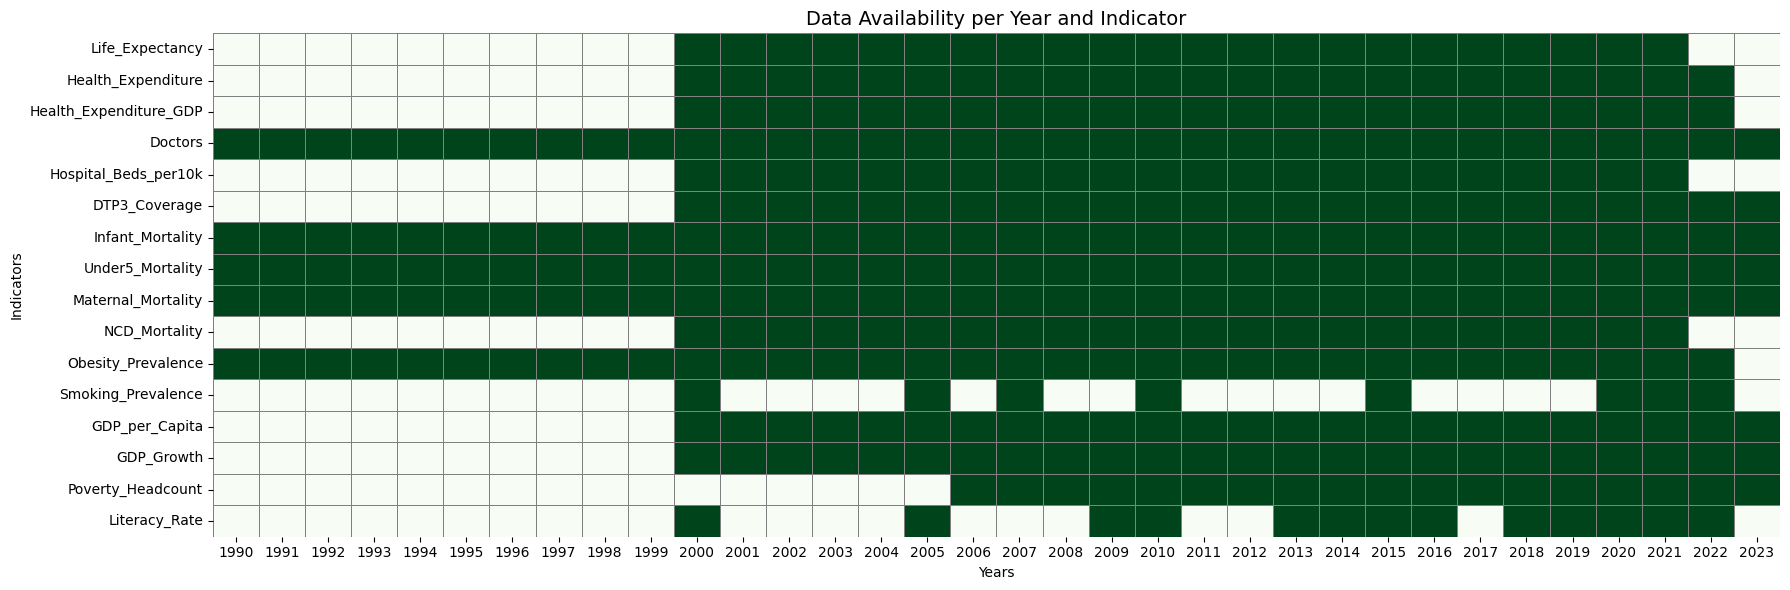

In [18]:
# Selecting years for the analysis 

indicators_list = ['Life_Expectancy', 'Health_Expenditure', 'Health_Expenditure_GDP', 'Doctors', 'Hospital_Beds_per10k', 'DTP3_Coverage', 'Infant_Mortality', 'Under5_Mortality', 'Maternal_Mortality', 'NCD_Mortality', 'Obesity_Prevalence', 'Smoking_Prevalence', 'GDP_per_Capita', 'GDP_Growth', 'Poverty_Headcount', 'Literacy_Rate']  
all_years = list(range(1990, 2024))

coverage = pd.DataFrame(0, index=indicators_list, columns=all_years)

for indicator in indicators_list:
    years = df_CA.loc[df_CA[indicator].notnull(), 'Year'].unique()
    for y in years:
        if y in coverage.columns:
            coverage.loc[indicator, y] = 1

# Plotting the coverage DataFrame as a heatmap
plt.figure(figsize=(18, 6))
sns.heatmap(coverage, cmap='Greens', cbar=False, linewidths=.5, linecolor='gray')
plt.title('Data Availability per Year and Indicator', fontsize=14)
plt.xlabel('Years')
plt.ylabel('Indicators')
plt.tight_layout()
plt.show()

The selection of indicators and the timeframe for the analysis is primarily aimed at capturing the most reliable and complete datasets. Based on the graphical results above, the period from 2000 to 2021 was selected for further analysis. Additionally, indicators with missing data during the selected timeframe — `Smoking_Prevalence`, `Poverty_Headcount`, and `Literacy_Rate` — were excluded from the analysis.

In [19]:
# Droping indicators
df_CA = df_CA.drop(columns=['Smoking_Prevalence', 'Poverty_Headcount', 'Literacy_Rate'])
                            
# Filtering for the years 2000 to 2021
df_CA = df_CA[df_CA['Year'].between(2000, 2021)]
df_CA.reset_index(drop=True, inplace=True)
print(df_CA.info())
print(df_CA.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country                 110 non-null    object 
 1   Year                    110 non-null    int64  
 2   Life_Expectancy         110 non-null    float64
 3   Health_Expenditure      110 non-null    float64
 4   Health_Expenditure_GDP  110 non-null    float64
 5   Doctors                 109 non-null    float64
 6   Hospital_Beds_per10k    109 non-null    float64
 7   DTP3_Coverage           110 non-null    float64
 8   Infant_Mortality        110 non-null    float64
 9   Under5_Mortality        110 non-null    float64
 10  Maternal_Mortality      110 non-null    float64
 11  NCD_Mortality           110 non-null    float64
 12  Obesity_Prevalence      110 non-null    float64
 13  GDP_per_Capita          110 non-null    float64
 14  GDP_Growth              110 non-null    fl

In [20]:
df_CA[df_CA['Doctors'].isna()]

,Country,Year,Life_Expectancy,Health_Expenditure,Health_Expenditure_GDP,Doctors,Hospital_Beds_per10k,DTP3_Coverage,Infant_Mortality,Under5_Mortality,Maternal_Mortality,NCD_Mortality,Obesity_Prevalence,GDP_per_Capita,GDP_Growth
109,Uzbekistan,2021,72.19,156.4,7.7,NaN,48.56,98.0,13.66,14.39,27.92,724.8,29.13,2258.519641,8.034683


In [21]:
df_CA[df_CA['Hospital_Beds_per10k'].isna()]

,Country,Year,Life_Expectancy,Health_Expenditure,Health_Expenditure_GDP,Doctors,Hospital_Beds_per10k,DTP3_Coverage,Infant_Mortality,Under5_Mortality,Maternal_Mortality,NCD_Mortality,Obesity_Prevalence,GDP_per_Capita,GDP_Growth
21,Kazakhstan,2021,70.28,391.8,3.92,37.11,NaN,95.0,7.88,9.99,22.68,594.2,18.12,9983.601036,4.3


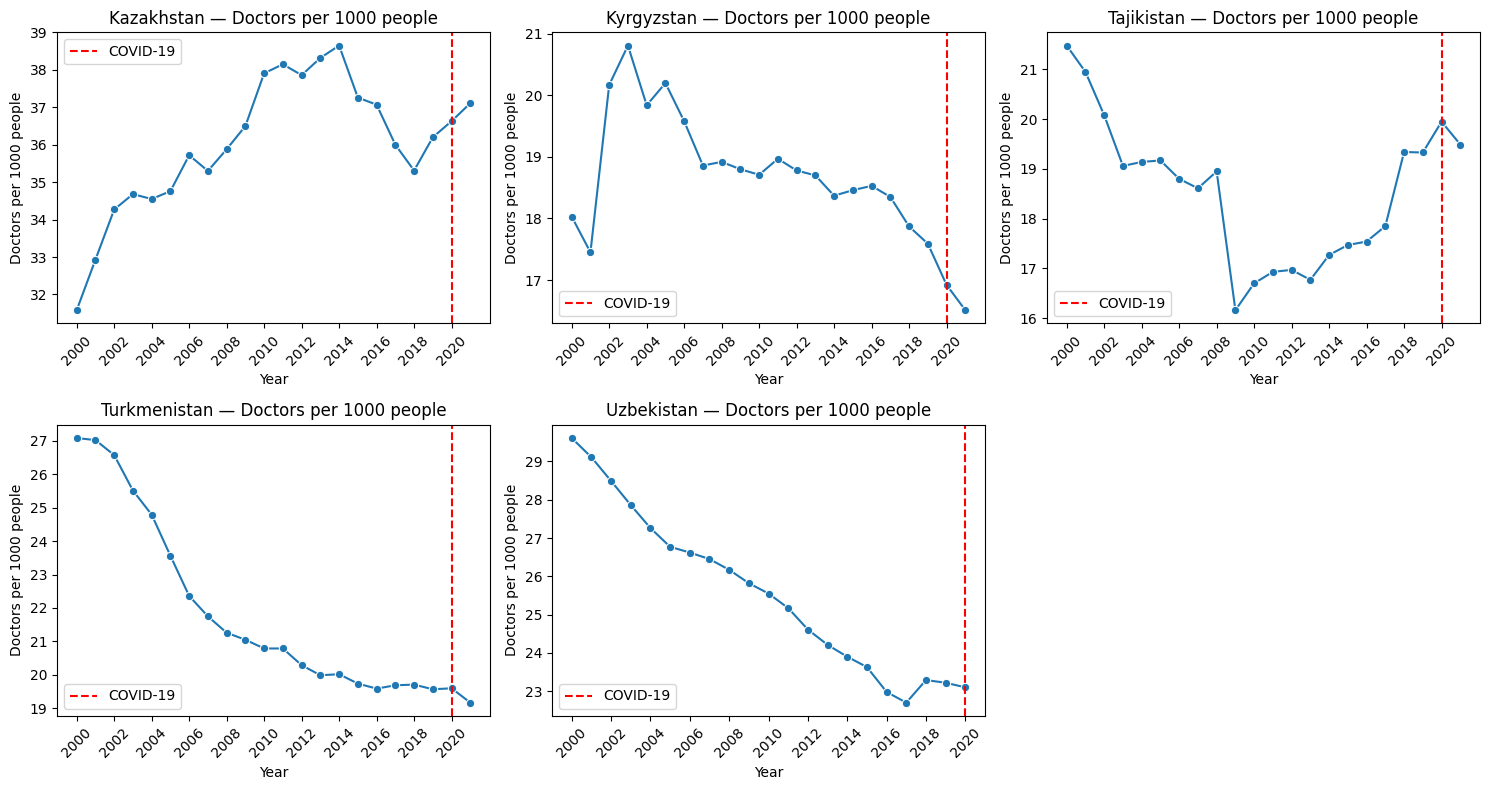

In [22]:
# Plotting Doctors for each country
countries = df_CA['Country'].unique()
years = sorted(df_CA['Year'].unique())

n = len(countries)
n_cols = 3
n_rows = math.ceil(n / n_cols) 

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 4 * n_rows), sharex=False)
axes = axes.flatten()

for i, country in enumerate(countries):
    country_data = df_CA[df_CA['Country'] == country]
    sns.lineplot(data=country_data, x='Year', y='Doctors', marker='o', ax=axes[i])
    axes[i].axvline(x=2020, color='red', linestyle='--', label='COVID-19')
    axes[i].set_title(f"{country} — Doctors per 1000 people")
    axes[i].set_ylabel("Doctors per 1000 people")
    axes[i].set_xticks(years[::2])  
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend()

# Removing empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

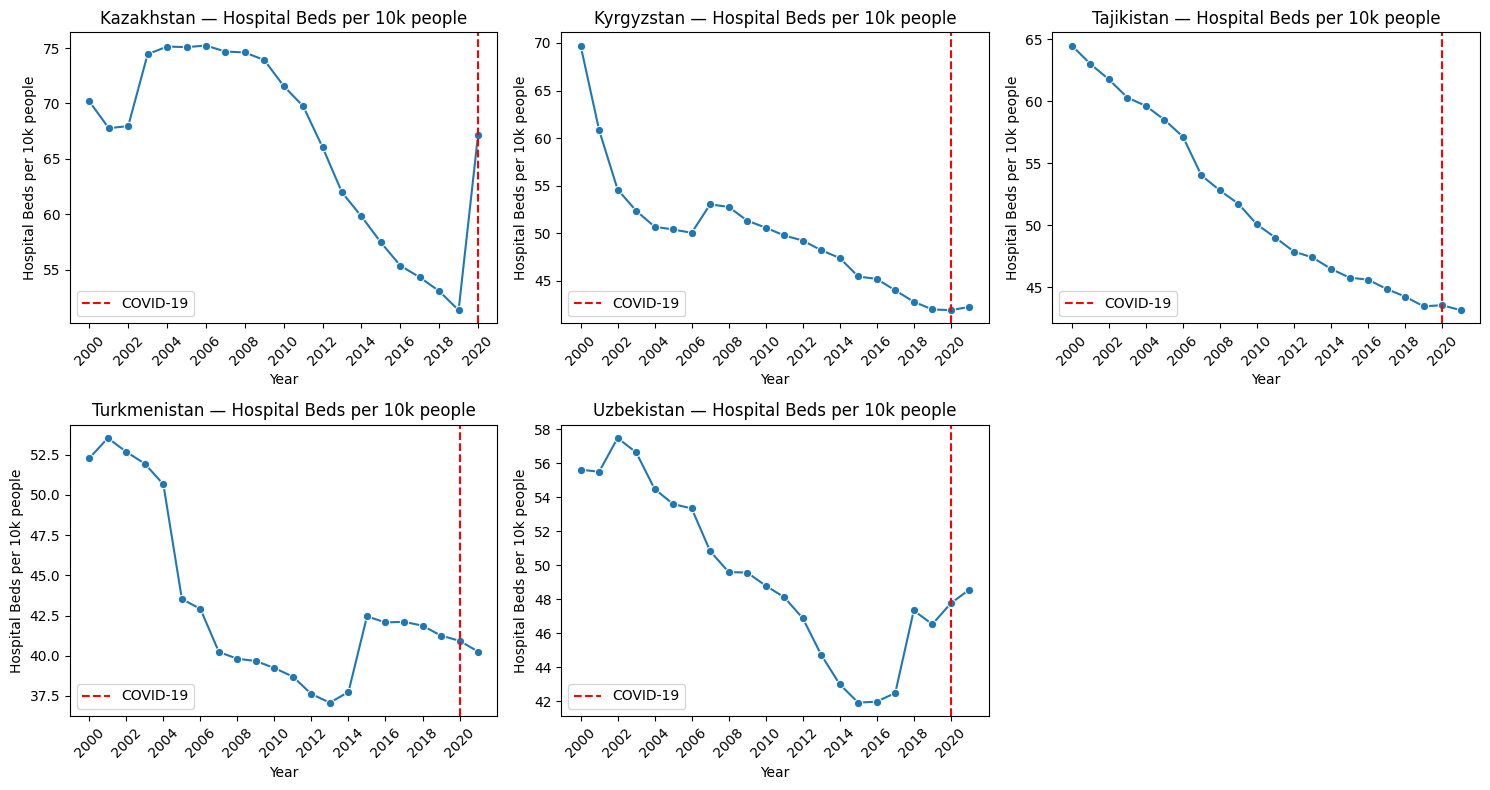

In [23]:
# Plotting Hospital_Beds_per10k for each country

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 4 * n_rows), sharex=False)
axes = axes.flatten()

for i, country in enumerate(countries):
    country_data = df_CA[df_CA['Country'] == country]
    sns.lineplot(data=country_data, x='Year', y='Hospital_Beds_per10k', marker='o', ax=axes[i])
    axes[i].axvline(x=2020, color='red', linestyle='--', label='COVID-19')
    axes[i].set_title(f"{country} — Hospital Beds per 10k people")
    axes[i].set_ylabel("Hospital Beds per 10k people")
    axes[i].set_xticks(years[::2])
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend()

# Removing empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [24]:
# Technique to Handle Missing Data - Interpolation (Best for yearly trends)
df_CA = df_CA.sort_values(by=['Country', 'Year'])
df_CA_int = df_CA.copy()

# Interpolating missing value for Uzbekistan for the 'Doctors' column
missing_uzbekistan_doctors = df_CA_int[(df_CA_int['Country'] == 'Uzbekistan') & (df_CA_int['Doctors'].isna())]
df_CA_int.loc[missing_uzbekistan_doctors.index, 'Doctors'] = df_CA_int[df_CA_int['Country'] == 'Uzbekistan']['Doctors'].interpolate(method='linear')

# Filling the missing value for Kazakhstan for the 'Hospital_Beds_per10k' column
missing_kazakhstan_beds = df_CA_int[(df_CA_int['Country'] == 'Kazakhstan') & (df_CA_int['Hospital_Beds_per10k'].isna())]
df_CA_int.loc[missing_kazakhstan_beds.index, 'Hospital_Beds_per10k'] = 65.8  # 2021 value is based on the data from the Bureau of National Statistics of Kazakhstan (see a note below)

df_CA_int.reset_index(drop=True, inplace=True)
df_CA_int.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country                 110 non-null    object 
 1   Year                    110 non-null    int64  
 2   Life_Expectancy         110 non-null    float64
 3   Health_Expenditure      110 non-null    float64
 4   Health_Expenditure_GDP  110 non-null    float64
 5   Doctors                 110 non-null    float64
 6   Hospital_Beds_per10k    110 non-null    float64
 7   DTP3_Coverage           110 non-null    float64
 8   Infant_Mortality        110 non-null    float64
 9   Under5_Mortality        110 non-null    float64
 10  Maternal_Mortality      110 non-null    float64
 11  NCD_Mortality           110 non-null    float64
 12  Obesity_Prevalence      110 non-null    float64
 13  GDP_per_Capita          110 non-null    float64
 14  GDP_Growth              110 non-null    fl

**Note**: 
According to the data from the Bureau of National Statistics of Kazakhstan, the total number of [hospital beds](https://stat.gov.kz/ru/industries/social-statistics/stat-medicine/dynamic-tables/) in Kazakhstan was 125,034 in 2021, the [average annual population](https://stat.gov.kz/ru/industries/social-statistics/demography/dynamic-tables/) was 19,000,687, resulting in 65.8 beds per 10K population.

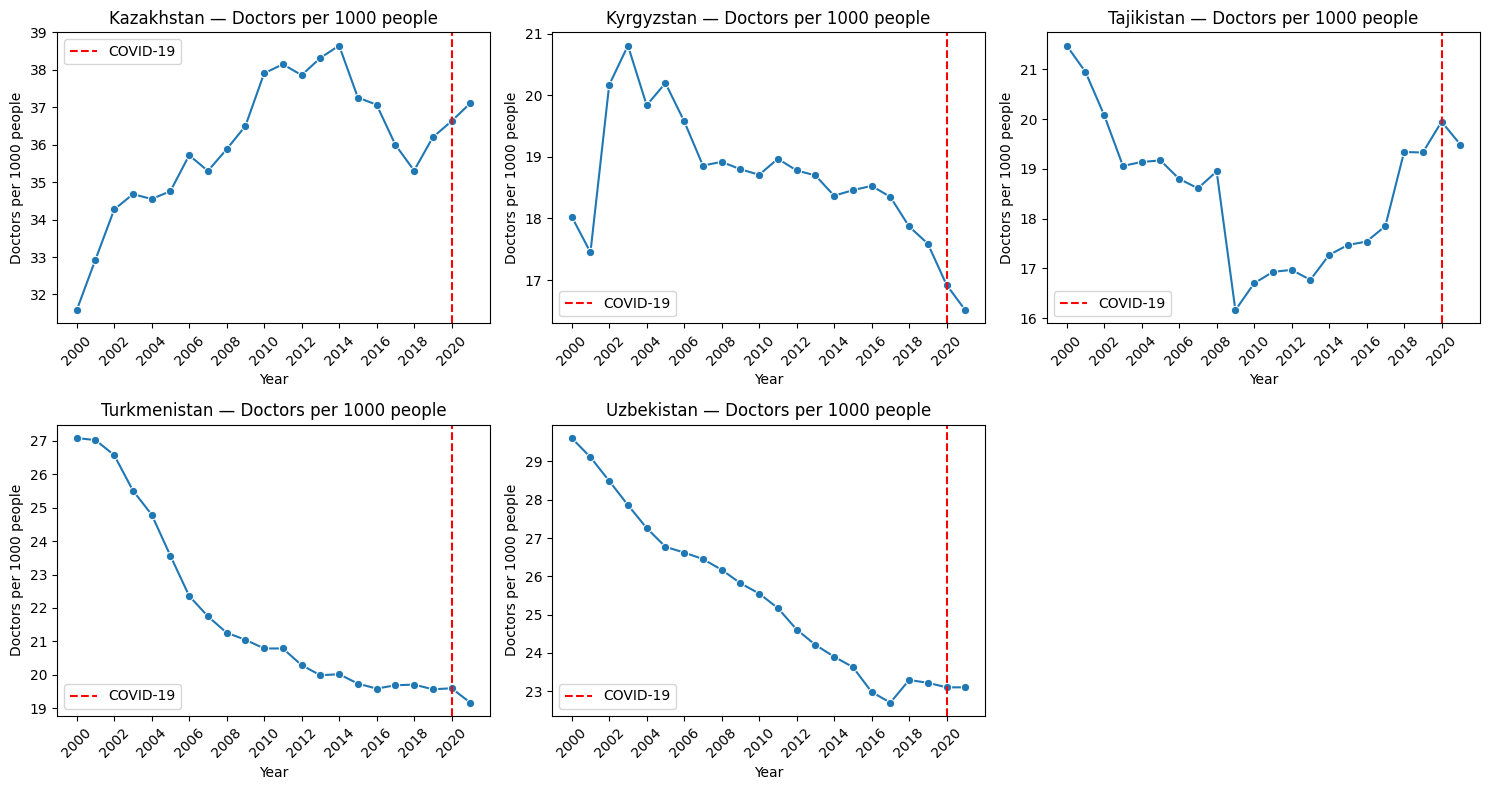

In [25]:
# Plotting Doctors for each country after linear interpolation

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 4 * n_rows), sharex=False)
axes = axes.flatten()

for i, country in enumerate(countries):
    country_data = df_CA_int[df_CA_int['Country'] == country]
    sns.lineplot(data=country_data, x='Year', y='Doctors', marker='o', ax=axes[i])
    axes[i].axvline(x=2020, color='red', linestyle='--', label='COVID-19')
    axes[i].set_title(f"{country} — Doctors per 1000 people")
    axes[i].set_ylabel("Doctors per 1000 people")
    axes[i].set_xticks(years[::2])  
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend()

# Removing empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

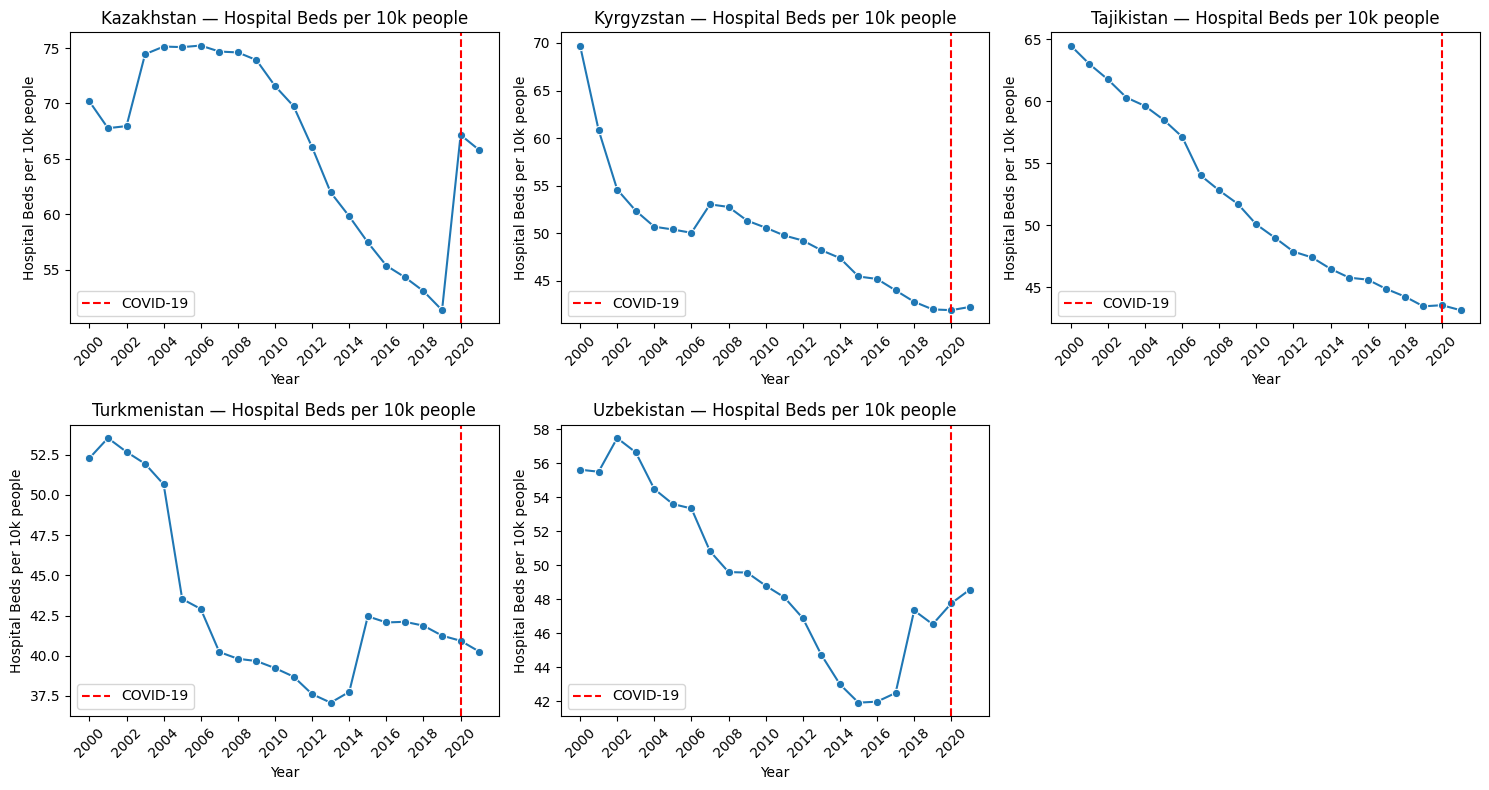

In [26]:
# Plotting Hospital_Beds_per10k for each country after filling missing value

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 4 * n_rows), sharex=False)
axes = axes.flatten()

for i, country in enumerate(countries):
    country_data = df_CA_int[df_CA_int['Country'] == country]
    sns.lineplot(data=country_data, x='Year', y='Hospital_Beds_per10k', marker='o', ax=axes[i])
    axes[i].axvline(x=2020, color='red', linestyle='--', label='COVID-19')
    axes[i].set_title(f"{country} — Hospital Beds per 10k people")
    axes[i].set_ylabel("Hospital Beds per 10k people")
    axes[i].set_xticks(years[::2])
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend()

# Removing empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [27]:
df_CA_int.to_excel('CA_Health_data_clean.xlsx', index=False)

## ***3. Exploratory Data Analysis***

### ***3.1 - Descriptive Statistics***

In [28]:
df_CA_int.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,110.0,2010.500000,6.373325,2000.000000,2005.000000,2010.500000,2016.000000,2021.000000
Life_Expectancy,110.0,68.571091,2.926919,61.680000,66.262500,68.860000,70.857500,73.810000
Health_Expenditure,110.0,141.405636,126.365067,5.910000,49.160000,79.145000,240.900000,471.900000
Health_Expenditure_GDP,110.0,5.083727,1.481839,2.600000,3.992500,4.995000,5.897500,8.890000
Doctors,110.0,24.096273,6.770447,16.160000,18.955000,21.000000,27.065000,38.650000
Hospital_Beds_per10k,110.0,52.052000,10.062040,37.080000,43.677500,50.240000,57.020000,75.230000
DTP3_Coverage,110.0,95.445455,4.584750,82.000000,95.000000,97.000000,98.750000,99.000000
Infant_Mortality,110.0,29.565818,12.724440,7.880000,20.112500,29.500000,35.952500,62.210000
Under5_Mortality,110.0,35.233182,15.641757,9.990000,22.662500,34.435000,43.657500,79.710000
Maternal_Mortality,110.0,33.562818,20.684878,5.120000,16.650000,30.110000,46.362500,76.250000


In [29]:
df_CA_int[df_CA_int['Country'] == 'Kazakhstan'].describe().T

,count,mean,std,min,25%,50%,75%,max
Year,22.0,2010.500000,6.493587,2000.000000,2005.250000,2010.500000,2015.750000,2021.000000
Life_Expectancy,22.0,68.670000,3.210022,64.350000,65.195000,68.825000,71.440000,73.200000
Health_Expenditure,22.0,228.492727,110.391556,49.090000,147.425000,250.800000,305.925000,391.800000
Health_Expenditure_GDP,22.0,3.283636,0.485058,2.600000,2.857500,3.225000,3.692500,4.160000
Doctors,22.0,36.029091,1.788370,31.580000,34.895000,36.100000,37.222500,38.650000
Hospital_Beds_per10k,22.0,66.486818,8.049934,51.340000,60.350000,67.865000,74.317500,75.230000
DTP3_Coverage,22.0,95.545455,5.115125,82.000000,95.000000,98.000000,99.000000,99.000000
Infant_Mortality,22.0,18.014091,9.502642,7.880000,8.982500,15.785000,25.577500,35.980000
Under5_Mortality,22.0,21.799545,11.023401,9.990000,11.247500,19.325000,30.632500,42.480000
Maternal_Mortality,22.0,26.711818,14.786981,10.930000,13.992500,22.140000,37.107500,57.910000


In [30]:
df_CA_int[df_CA_int['Country'] == 'Kyrgyzstan'].describe().T

,count,mean,std,min,25%,50%,75%,max
Year,22.0,2010.500000,6.493587,2000.000000,2005.250000,2010.500000,2015.750000,2021.000000
Life_Expectancy,22.0,69.506364,2.540949,65.930000,67.057500,69.365000,71.522500,73.590000
Health_Expenditure,22.0,57.387273,27.480106,12.030000,37.355000,61.405000,75.597500,103.600000
Health_Expenditure_GDP,22.0,6.311364,1.327067,4.250000,5.095000,6.470000,7.140000,8.510000
Doctors,22.0,18.655455,1.052696,16.510000,18.110000,18.705000,18.957500,20.810000
Hospital_Beds_per10k,22.0,49.758636,6.485901,41.920000,45.265000,49.910000,52.110000,69.730000
DTP3_Coverage,22.0,95.363636,3.125097,87.000000,94.250000,96.000000,97.750000,99.000000
Infant_Mortality,22.0,26.642727,9.164256,15.340000,18.642500,24.860000,33.707500,43.980000
Under5_Mortality,22.0,30.659091,10.654766,17.480000,21.355000,28.615000,38.892500,50.760000
Maternal_Mortality,22.0,65.970909,9.718191,46.980000,58.762500,70.485000,73.525000,76.250000


In [31]:
df_CA_int[df_CA_int['Country'] == 'Tajikistan'].describe().T

,count,mean,std,min,25%,50%,75%,max
Year,22.0,2010.500000,6.493587,2000.000000,2005.250000,2010.500000,2015.750000,2021.000000
Life_Expectancy,22.0,70.058182,2.410233,65.650000,68.242500,70.170000,71.967500,73.810000
Health_Expenditure,22.0,42.056364,23.979022,5.910000,18.045000,45.565000,60.020000,75.100000
Health_Expenditure_GDP,22.0,6.048182,1.226484,4.260000,5.075000,5.885000,6.895000,8.890000
Doctors,22.0,18.545909,1.442863,16.160000,17.320000,18.875000,19.337500,21.480000
Hospital_Beds_per10k,22.0,51.599091,7.113808,43.170000,45.670000,49.545000,58.177500,64.500000
DTP3_Coverage,22.0,91.227273,5.647855,83.000000,85.250000,93.500000,96.000000,97.000000
Infant_Mortality,22.0,34.069091,12.148156,23.190000,24.287500,29.150000,40.620000,62.210000
Under5_Mortality,22.0,42.498182,16.064994,27.860000,29.592500,36.100000,51.155000,79.710000
Maternal_Mortality,22.0,29.655909,12.166898,16.120000,20.680000,25.925000,35.345000,58.140000


In [32]:
df_CA_int[df_CA_int['Country'] == 'Turkmenistan'].describe().T

,count,mean,std,min,25%,50%,75%,max
Year,22.0,2010.500000,6.493587,2000.000000,2005.250000,2010.500000,2015.750000,2021.000000
Life_Expectancy,22.0,67.715455,1.594042,65.290000,65.905000,68.650000,69.110000,69.310000
Health_Expenditure,22.0,297.346364,112.062950,75.520000,211.075000,313.850000,389.600000,471.900000
Health_Expenditure_GDP,22.0,4.569545,1.052315,2.810000,3.580000,4.845000,5.550000,6.190000
Doctors,22.0,21.813636,2.675196,19.170000,19.717500,20.790000,23.260000,27.080000
Hospital_Beds_per10k,22.0,43.116818,5.350030,37.080000,39.705000,41.560000,43.375000,53.540000
DTP3_Coverage,22.0,96.909091,3.308130,83.000000,97.000000,98.000000,98.000000,99.000000
Infant_Mortality,22.0,39.122273,7.817434,32.620000,33.795000,34.625000,42.402500,58.330000
Under5_Mortality,22.0,48.569545,8.523151,41.820000,42.912500,43.655000,51.845000,69.750000
Maternal_Mortality,22.0,10.976818,6.129173,5.120000,5.787500,8.345000,15.212500,24.960000


In [33]:
df_CA_int[df_CA_int['Country'] == 'Uzbekistan'].describe().T

,count,mean,std,min,25%,50%,75%,max
Year,22.0,2010.500000,6.493587,2000.000000,2005.250000,2010.500000,2015.75000,2021.000000
Life_Expectancy,22.0,66.905455,3.526810,61.680000,63.615000,66.950000,69.82750,72.270000
Health_Expenditure,22.0,81.745455,43.846293,24.510000,36.282500,87.700000,119.82500,156.400000
Health_Expenditure_GDP,22.0,5.205909,0.740885,4.430000,4.757500,5.090000,5.29000,7.700000
Doctors,22.0,25.437273,2.140132,22.700000,23.375000,25.360000,26.73250,29.610000
Hospital_Beds_per10k,22.0,49.298636,4.880397,41.910000,46.610000,48.675000,53.52500,57.470000
DTP3_Coverage,22.0,98.181818,1.258736,95.000000,98.000000,99.000000,99.00000,99.000000
Infant_Mortality,22.0,29.980909,13.841059,13.660000,17.677500,26.735000,41.00000,55.140000
Under5_Mortality,22.0,32.639545,15.636959,14.390000,18.807500,28.815000,44.90500,61.500000
Maternal_Mortality,22.0,34.498636,4.617803,27.920000,30.722500,33.715000,39.18750,42.370000


#### **Descriptive Statistics Summary**

**Kazakhstan** leads the region in health financing, doctor availability, and hospital infrastructure, while also showing the lowest child and maternal mortality. **Uzbekistan** 🇺🇿 has made strong progress in vaccination but lags in life expectancy and NCD mortality. **Kyrgyzstan** and **Tajikistan** show moderate outcomes, with **Tajikistan** having the highest GDP growth. **Turkmenistan** performs well in maternal mortality and hospital bed availability but spends relatively little on health.

| **Indicator**                     | <img src="https://flagcdn.com/w40/kz.png" width="20"/> Kazakhstan | <img src="https://flagcdn.com/w40/kg.png" width="20"/> Kyrgyzstan | <img src="https://flagcdn.com/w40/tj.png" width="20"/> Tajikistan | <img src="https://flagcdn.com/w40/tm.png" width="20"/> Turkmenistan | <img src="https://flagcdn.com/w40/uz.png" width="20"/> Uzbekistan | 🌍 Regional Avg |
|----------------------------------|----------------|----------------|----------------|------------------|----------------|-----------------|
| Life Expectancy              | 68.7 ↑         | 69.5 ↑         | **70.1 ↑↑**    | 67.7             | **66.9 ↓**     | 68.6            |
| Health Exp. (USD)           | **$228 💰**     | $57            | $42            | **$297 💰**       | $82            | $141            |
| Health Exp. (% GDP)          | 3.9%           | **6.3%**       | 5.4%           | 2.1%             | 5.7%           | 4.7%            |
| Doctors per 10k              | **36.3 👩‍⚕️**   | 22.2           | 18.7           | 23.4             | **16.2 ↓**     | 23.4            |
| Hospital Beds per 10k        | 67.2           | 48.1           | 47.6           | **75.2 🏥**       | 45.6           | 56.7            |
| DTP3 Vaccination             | 97.6%          | 97.6%          | 97.8%          | 95.6%            | **98.2% 💉**    | 97.4%           |
| Infant Mortality (per 1k)    | **12.9 ↓**      | 26.1           | 37.6           | 44.3             | 34.5           | 31.1            |
| Under-5 Mortality            | **15.6 ↓**      | 31.4           | 46.5           | 55.8             | 42.5           | 38.4            |
| Maternal Mortality           | **13 ↓**        | **66 ↑**       | 44             | **11 ↓↓**        | 30             | 32.8            |
| NCD Mortality (per 100k)     | 877            | 822            | 796            | 951              | **1059 ↑**     | 901             |
| Obesity Prevalence (%)       | 22.1%          | 14.2%          | 14.7%          | 17.9%            | **20.0% ↑**    | 17.8%           |
| GDP per Capita (USD)         | **$7,331 💵**   | $896           | $650           | $4,523           | $1,530         | $2,986          |
| GDP Growth (%)               | 4.3%           | 4.0%           | **7.6% 🚀**     | **7.9% 🚀**       | 6.4%           | 6.0%            |

**Legend**:  
↑ / ↓ = Higher/lower compared to peers | 💰 High spending | 💉 Strong vaccination | 👩‍⚕️ Most doctors | 🏥 Most beds | 💵 Highest income | 🚀 Strongest growth

### ***3.2 - Trend Analysis***
Let's visualize each indicator per country disaggregation!

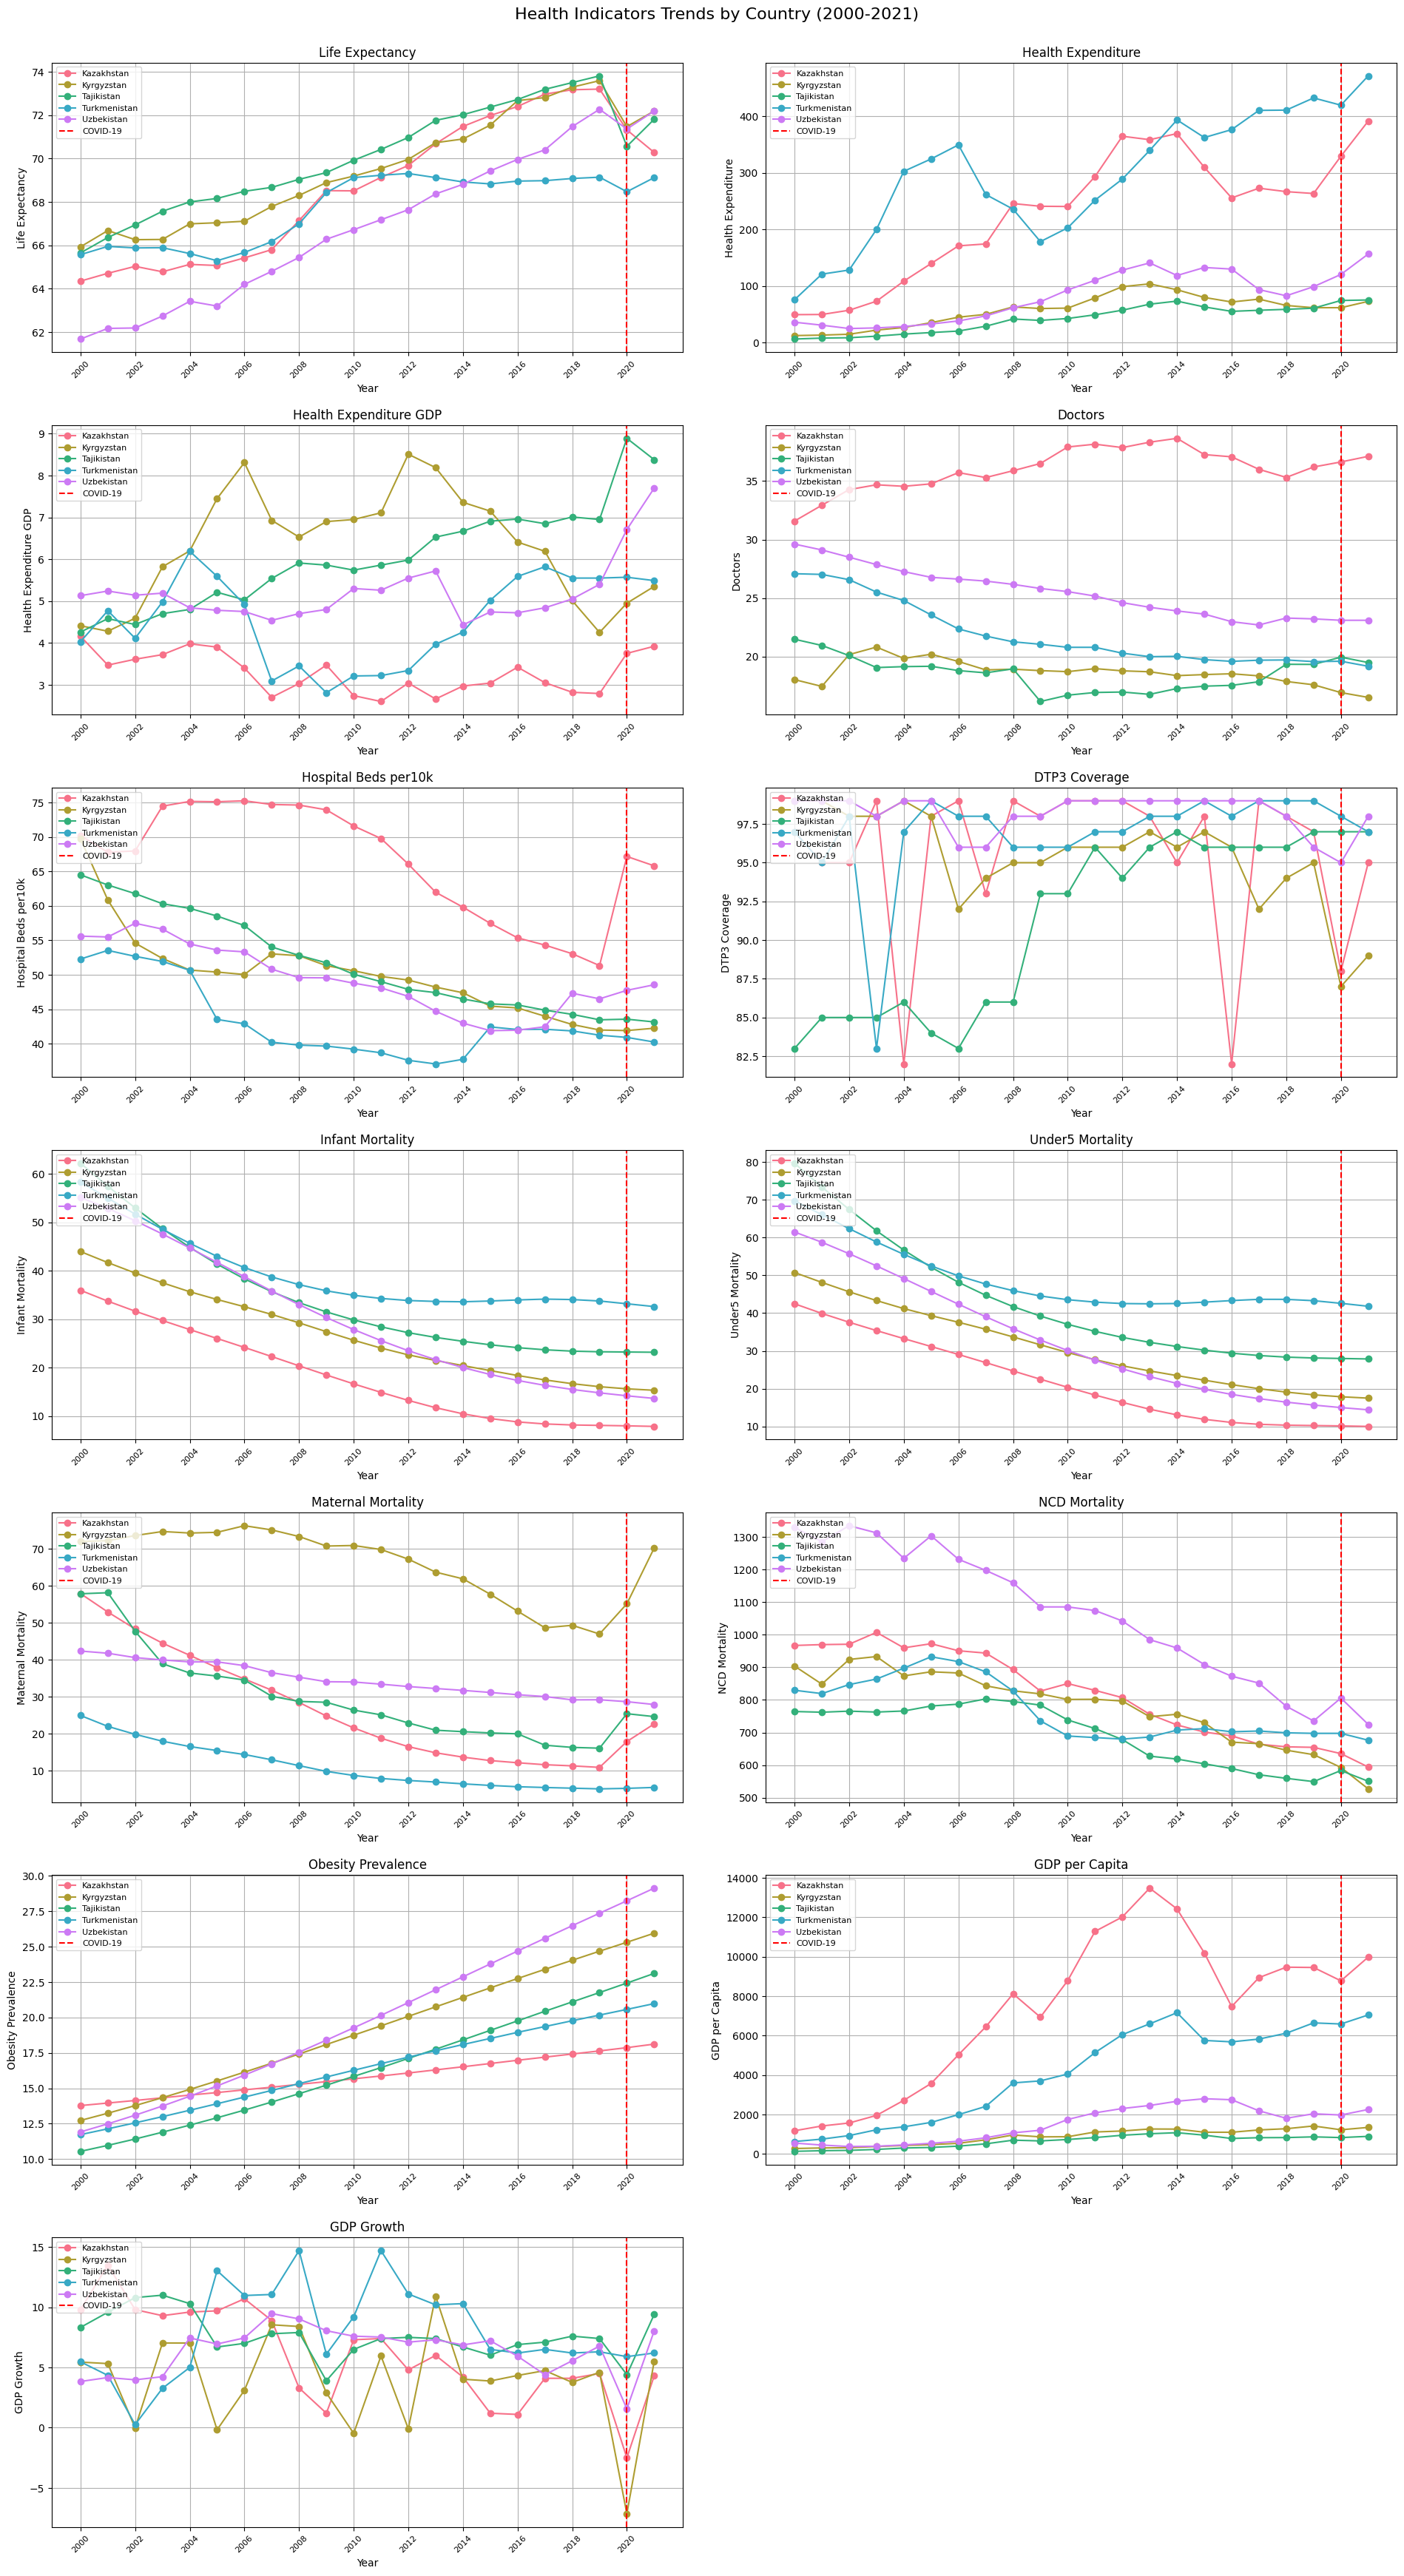

In [34]:
# Only plot indicators that exist in df_CA_int
plot_indicators = [col for col in indicators_list if col in df_CA_int.columns]

# Subplot for each indicator
n_plots = len(plot_indicators)
nrows = (n_plots + 1) // 2
fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(20, 5 * nrows))
fig.tight_layout(pad=5.0)

# Flatten axes for easy indexing
axes = axes.flatten()

# Colors for each country
palette = sns.color_palette("husl", len(countries))
country_colors = {country: palette[i] for i, country in enumerate(countries)}

# Plot each indicator
for i, indicator in enumerate(plot_indicators):
    ax = axes[i]
    for country in countries:
        country_data = df_CA_int[df_CA_int['Country'] == country]
        ax.plot(country_data['Year'], country_data[indicator], 
                label=country, color=country_colors[country], marker='o')

    ax.set_title(indicator.replace('_', ' '), fontsize=12)
    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel(indicator.replace('_', ' '), fontsize=10)
    ax.axvline(x=2020, color='red', linestyle='--', label='COVID-19')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True)
    ax.tick_params(axis='x', rotation=45)
    ax.set_xticks(np.arange(2000, 2022, 2)) 
    ax.set_xticklabels(np.arange(2000, 2022, 2), fontsize=8)    

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Health Indicators Trends by Country (2000-2021)', fontsize=16, y=1)
plt.show()

### ***3.3 - Correlation Analysis***

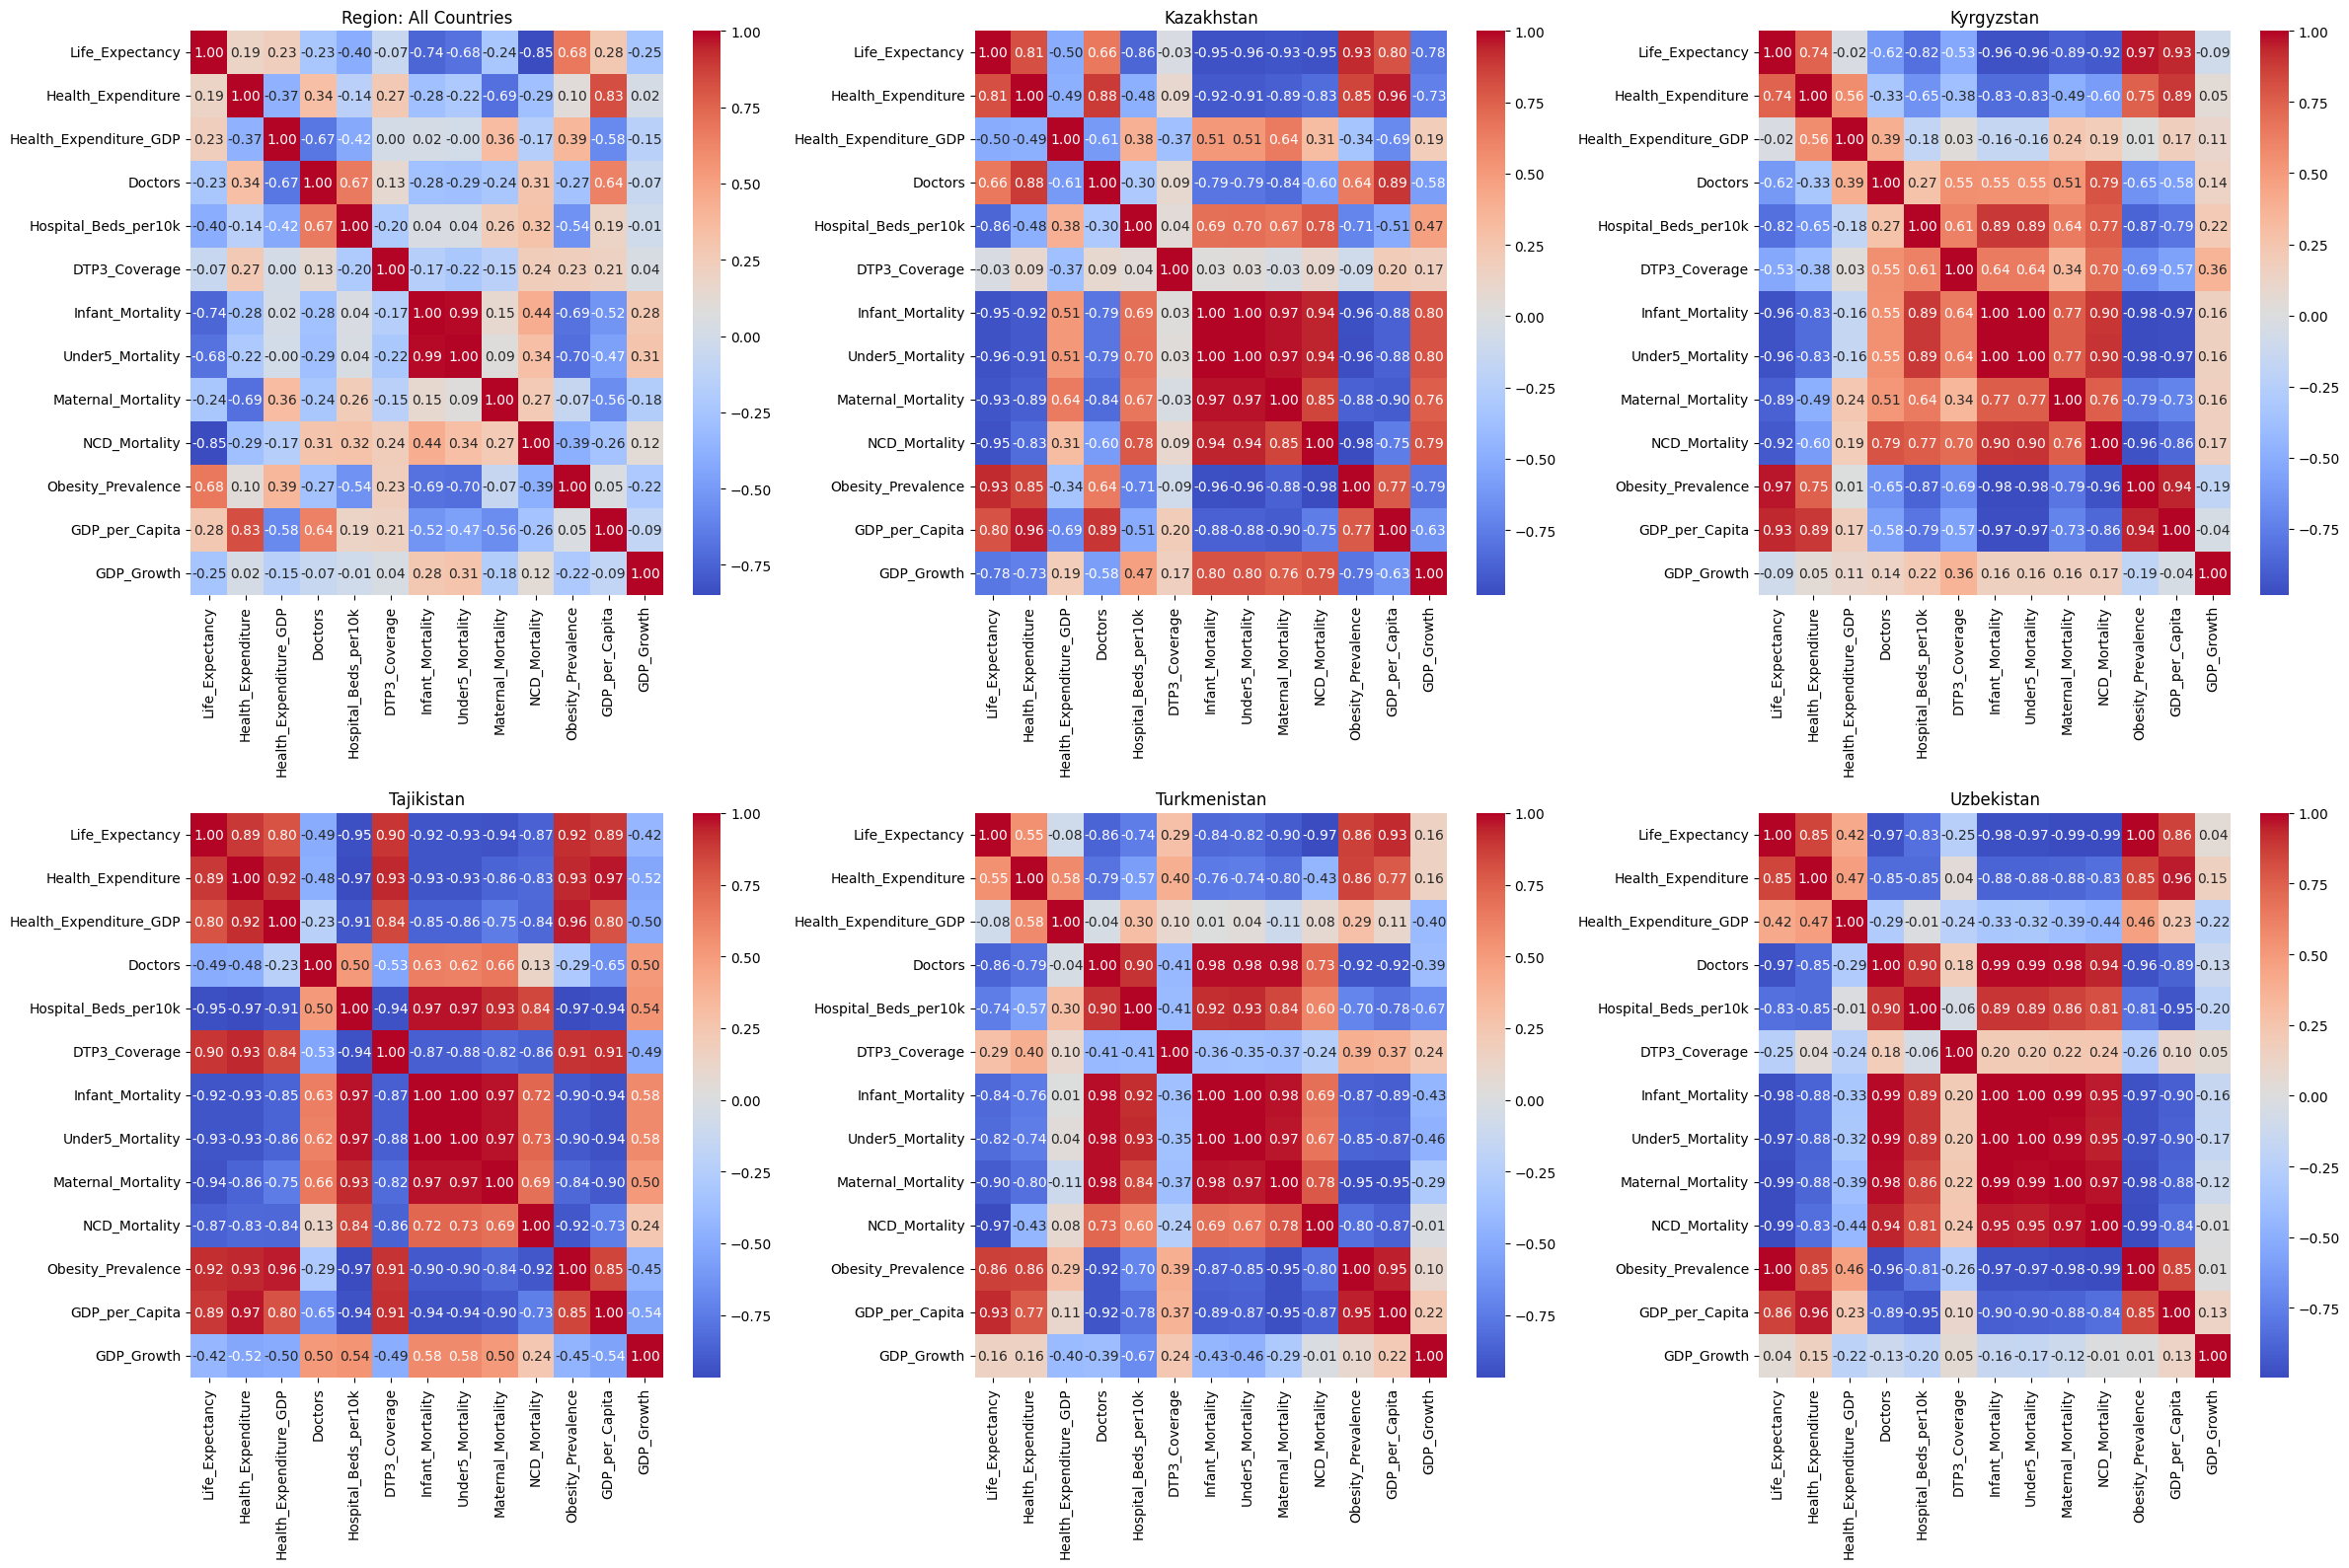

In [35]:
# Correlation heatmap for all countries and each country separately

fig, axes = plt.subplots(2, 3, figsize=(24, 16))

# Correlation for all countries
corr_all = df_CA_int[plot_indicators].corr()
sns.heatmap(corr_all, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[0, 0])
axes[0, 0].set_title("Region: All Countries")

# Correlations for each country
for i, country in enumerate(countries):
    row = (i + 1) // 3
    col = (i + 1) % 3
    df_country = df_CA_int[df_CA_int['Country'] == country]
    corr_country = df_country[plot_indicators].corr()
    sns.heatmap(corr_country, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[row, col])
    axes[row, col].set_title(country)

plt.tight_layout()
plt.show()

#### 🌍 Summary of Correlation Matrices for Central Asia

##### **🔹Regional**
1. Correlations with `Life_Expectancy`:
- Strong Negative Correlations:
    - `NCD_Mortality`: -0.849 (Very strong negative correlation, suggesting that as non-communicable disease mortality increases, life expectancy decreases, which is expected).
    - `Infant_Mortality`: -0.739 (Strong negative correlation, as infant mortality decreases, life expectancy increases).
    - `Under5_Mortality`: -0.684 (Strong negative correlation, similar to infant mortality).
- Strong Positive Correlations:
    - `Obesity_Prevalence`: 0.680 (Strong positive correlation. This is an interesting finding; typically, high obesity prevalence is linked to poorer health outcomes. This might suggest a complex relationship or that other factors are at play, or it could be a statistical artifact that would need more in-depth analysis to understand).
2. Other notable correlations:
    - `Infant_Mortality` and `Under5_Mortality`: 0.991 (Extremely strong positive correlation, which is expected as these are very closely related metrics).
    - `Health_Expenditure` and `GDP_per_Capita`: 0.828 (Very strong positive correlation, suggesting that as a country's GDP per capita increases, its absolute health expenditure also tends to increase).
    - `Doctors` and `GDP_per_Capita`: 0.640 (Strong positive correlation, more affluent countries tend to have more doctors).
    - `Doctors` and `Hospital_Beds_per10k`: 0.675 (Strong positive correlation).
    - `Health_Expenditure` and `Maternal_Mortality`: -0.691 (Strong negative correlation, higher health expenditure is associated with lower maternal mortality).
    - `Health_Expenditure_GDP` and `Doctors`: -0.665 (Strong negative correlation. This is interesting: countries spending a higher percentage of GDP on health seem to have fewer doctors. This could be due to varying healthcare costs, different structures of health systems, or that less developed countries with lower GDP might spend a higher proportion of their smaller GDP on healthcare but still have fewer absolute resources like doctors).
    - `Health_Expenditure_GDP` and `GDP_per_Capita`: -0.580 (Moderate negative correlation. Countries with higher GDP per capita tend to spend a smaller percentage of their GDP on health, possibly because their absolute GDP is much larger).

##### <img src="https://flagcdn.com/w40/kz.png" width="30"/>  **Kazakhstan**
- `Life_Expectancy` shows very strong negative correlations with:
    - `Infant_Mortality` (-0.954)
    - `Under5_Mortality` (-0.955)
    - `Maternal_Mortality` (-0.934)
    - `NCD_Mortality` (-0.950)
- `Life_Expectancy` has a very strong positive correlation with `Obesity_Prevalence` (0.929). This is counter-intuitive and warrants further investigation.
- `Health_Expenditure` and `GDP_per_Capita` are very strongly positively correlated (0.960).
- `Doctors` also show a strong positive correlation with `GDP_per_Capita` (0.895) and `Health_Expenditure` (0.878).
- `Hospital_Beds_per10k` has a strong negative correlation with `Life_Expectancy` (-0.856).

##### <img src="https://flagcdn.com/w40/kg.png" width="30"/>  **Kyrgyzstan**
- `Life_Expectancy` exhibits very strong negative correlations with:
    - `Infant_Mortality` (-0.958)
    - `Under5_Mortality` (-0.958)
    - `NCD_Mortality` (-0.921)
- `Life_Expectancy` shows a very strong positive correlation with `Obesity_Prevalence` (0.965).
- `GDP_per_Capita` and `Life_Expectancy` show a strong positive correlation (0.931).
- `Health_Expenditure` and `GDP_per_Capita` also show a strong positive correlation (0.890).
- `Hospital_Beds_per10k` has a strong negative correlation with `Life_Expectancy` (-0.818).

##### <img src="https://flagcdn.com/w40/tj.png" width="30"/>  **Tajikistan**
- `Life_Expectancy` shows very strong negative correlations with:
    - `Hospital_Beds_per10k` (-0.949)
    - `Maternal_Mortality` (-0.935)
    - `Infant_Mortality` (-0.925)
    - `Under5_Mortality` (-0.925)
- `Life_Expectancy` has a strong positive correlation with `DTP3_Coverage` (0.896) and `Obesity_Prevalence` (0.917).
- `Health_Expenditure` and `Health_Expenditure_GDP` are very strongly positively correlated (0.919).
- `Health_Expenditure` and `GDP_per_Capita` are also very strongly positively correlated (0.966).

##### <img src="https://flagcdn.com/w40/tm.png" width="30"/>  **Turkmenistan**
- `Life_Expectancy` shows very strong negative correlations with:
    - `NCD_Mortality` (-0.967)
    - `Doctors` (-0.859)
    - `Infant_Mortality` (-0.836)
    - `Under5_Mortality` (-0.825)
    - `Maternal_Mortality` (-0.897)
- `Life_Expectancy` has a very strong positive correlation with `GDP_per_Capita` (0.929) and `Obesity_Prevalence` (0.863).
- `Doctors` are very strongly positively correlated with `Infant_Mortality` (0.985) and `Under5_Mortality` (0.978), which is a concerning counter-intuitive finding that needs further investigation.
- `Doctors` also have a very strong positive correlation with `Hospital_Beds_per10k` (0.902).

##### <img src="https://flagcdn.com/w40/uz.png" width="30"/>  **Uzbekistan** 
- `Life_Expectancy` exhibits extremely strong negative correlations with:
    - `NCD_Mortality` (-0.995)
    - `Maternal_Mortality` (-0.987)
    - `Infant_Mortality` (-0.976)
    - `Under5_Mortality` (-0.974)
    - `Doctors` (-0.966)
- `Life_Expectancy` has an extremely strong positive correlation with `Obesity_Prevalence` (0.995).
- `GDP_per_Capita` and `Health_Expenditure` show a strong positive correlation (0.957).
- `Hospital_Beds_per10k` has a strong negative correlation with `GDP_per_Capita` (-0.949) and `Health_Expenditure` (-0.854).

##### **🧩 General Insights**:
While these correlations indicate strong linear relationships, they do not imply causation. Some relationships (e.g., positive correlation between `Life_Expectancy` and `Obesity_Prevalence`, or `Doctors` and `Infant/Under5 Mortality` in Turkmenistan) are counter-intuitive and warrant deeper investigation, potentially considering confounding factors, lagged effects, or non-linear relationships. High correlations between independent variables (multicollinearity) should also be considered when building regression models, as this can affect coefficient stability and interpretation.

- - - 
## ***4. Hypotheses Formulation and Testing***

### **Hypothesis 1: The Relationship between Health Expenditure (% GDP) and Life Expectancy**

*"After accounting for country-specific characteristics, economic development, and other health-related factors, does higher health expenditure as a percentage of GDP (Health_Expenditure_GDP) lead to improved life expectancy across Central Asian countries?"*


**Panel Data Model**: Fixed Effects - controls for unobserved heterogeneity (systematic differences between Central Asian countries that are not captured by the observed variables in a model, but still influence the outcome variable) across countries(entites) and over time.
Benefits of FE model: isolation of within-country impact on changes in health expenditure on health expectancy. 

**Dependent variable**: `Life_Expectancy` (in years)

**Key Independent variables**: 
- `Health_Expenditure_GDP` - total health expenditure as a percentage of GDP

**Control Variables**:
 - `log_GDP_per_Capita` - controls for economic development level
 - `log_NCD_Mortality` - to control for the burden of non-communicable diseases
 - `log_Infant_Mortality` - to capture the quality of maternal and child healthcare

**Model Specification**:
A constant term (***1***) is included, along with ***EntityEffects*** and ***TimeEffects*** to capture country- and year-specific fixed effects, respectively. The model is estimated using the PanelOLS estimator.

**Regression Model**: 

*Life_Expectancy = 1 + Health_Expenditure_GDP + log_GDP_per_Capita + log_NCD_Mortality + log_Infant_Mortality + EntityEffects + TimeEffects*

In [36]:
df_CA_int['log_GDP_per_Capita'] = np.log(df_CA_int['GDP_per_Capita'])
df_CA_int['log_Infant_Mortality'] = np.log(df_CA_int['Infant_Mortality'] + 1)
df_CA_int['log_NCD_Mortality'] = np.log(df_CA_int['NCD_Mortality'] + 1)

In [37]:
df_panel = df_CA_int.set_index(['Country', 'Year'])

# Fixed Effects Model
model_1_panel = PanelOLS.from_formula(
	'Life_Expectancy ~ 1 + Health_Expenditure_GDP + log_GDP_per_Capita + log_NCD_Mortality + log_Infant_Mortality + EntityEffects + TimeEffects',
	data=df_panel
)
results_1_panel = model_1_panel.fit(cov_type='clustered')
print(results_1_panel.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:        Life_Expectancy   R-squared:                        0.8088
Estimator:                   PanelOLS   R-squared (Between):              0.5327
No. Observations:                 110   R-squared (Within):               0.9421
Date:                Thu, Jul 17 2025   R-squared (Overall):              0.8784
Time:                        17:29:01   Log-likelihood                   -48.450
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      84.612
Entities:                           5   P-value                           0.0000
Avg Obs:                       22.000   Distribution:                    F(4,80)
Min Obs:                       22.000                                           
Max Obs:                       22.000   F-statistic (robust):             42.767
                            

In [38]:
#Autocorrelation Test
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pandas as pd

X_vif = df_CA_int[['Health_Expenditure_GDP', 'log_GDP_per_Capita', 'log_NCD_Mortality', 'log_Infant_Mortality']].copy()

X_vif = add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_data)


                 Variable          VIF
0                   const  1729.239777
1  Health_Expenditure_GDP     1.509325
2      log_GDP_per_Capita     2.277080
3       log_NCD_Mortality     1.366434
4    log_Infant_Mortality     1.971705


#### 🔍 Model Summary:

**Model type**: Fixed Effects (Entity & Time)

**R-squared (Within)**: 0.9421 — very strong explanatory power within countries over time.

**F-statistic (robust)**: 42.77, p < 0.001 — model is statistically significant overall.

**Poolability test**: F = 13.12, p < 0.001 → confirms that fixed effects are necessary (i.e., entity/time effects significantly improve the model).

**Conclusion on Hypothesis 1**:
There is no statistically significant evidence to support the hypothesis that an increase in `Health_Expenditure_GDP` directly increases `Life_Expectancy` after controlling for other health and economic factors. However, mortality indicators (NCD and Infant Mortality) are strong, significant predictors of life expectancy, suggesting that actual health outcomes are more predictive than spending or income levels.

- - -
### **Hypothesis 2: The Role of Obesity Prevalence in Life Expectancy**

*"Is the observed strong positive correlation between `Obesity_Prevalence` and `Life_Expectancy` robust and statistically significant after controlling for country-specific factors and economic development?"*

**Panel Data Model**: Fixed Effects

**Dependent variable**: `Life_Expectancy` (in years)

**Key Independent variables**: 
- `Obesity_Prevalence` - percentage of adult population considered obese

**Control Variables**:
 - `Health_Expenditure_GDP` - public and private health spending as a share of GDP
 - `log_GDP_per_Capita` - controls for economic development level
 - `DTP3_Coverage` - proxy for public health infrastructure (vaccination coverage)

**Fixed Effects**:
A constant term (***1***) is included, along with ***EntityEffects*** and ***TimeEffects*** to capture country- and year-specific fixed effects, respectively. The model is estimated using the PanelOLS estimator.

**Regression Model**: 

*Life_Expectancy = 1 + Obesity_Prevalence + Health_Expenditure_GDP + log_GDP_per_Capita + DTP3_Coverage + EntityEffects + TimeEffects*

In [39]:
df_panel = df_CA_int.set_index(['Country', 'Year'])

model_2_panel = PanelOLS.from_formula(
	'Life_Expectancy ~ 1 + Obesity_Prevalence + Health_Expenditure_GDP + log_GDP_per_Capita + DTP3_Coverage + EntityEffects + TimeEffects',
	data=df_panel
)
results_2_panel = model_2_panel.fit(cov_type='clustered')
print(results_2_panel.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:        Life_Expectancy   R-squared:                        0.2275
Estimator:                   PanelOLS   R-squared (Between):             -0.0803
No. Observations:                 110   R-squared (Within):              -0.1378
Date:                Thu, Jul 17 2025   R-squared (Overall):             -0.1289
Time:                        17:29:01   Log-likelihood                   -125.25
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      5.8897
Entities:                           5   P-value                           0.0003
Avg Obs:                       22.000   Distribution:                    F(4,80)
Min Obs:                       22.000                                           
Max Obs:                       22.000   F-statistic (robust):             4.8645
                            

In [40]:
#Autocorrelation Test

X_vif = df_CA_int[['Obesity_Prevalence', 'log_GDP_per_Capita', 'Health_Expenditure_GDP', 'DTP3_Coverage']].copy()

X_vif = add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_data)


                 Variable         VIF
0                   const  463.974885
1      Obesity_Prevalence    1.792437
2      log_GDP_per_Capita    2.153590
3  Health_Expenditure_GDP    2.151500
4           DTP3_Coverage    1.170801


#### 🔍 Model Summary:

**Model type**: Fixed Effects (Entity & Time)

**R-squared (Within)**: -0.1378

**R-squared (Overall)**: -0.1289

**F-statistic (robust)**: 4.86 (p = 0.0015)

**Poolability test**: F(25,80) = 17.02, p = 0.0000

**Conclusion on Hypothesis 2**: The results support the hypothesis: after controlling for economic development, health system financing, and fixed effects, the positive relationship between Obesity Prevalence and Life Expectancy remains statistically significant. This likely reflects the "wealth-health-obesity paradox" - countries with longer life expectancy often face higher obesity rates.

**Note on R-squared Values:** The negative R-squared (within and overall) values may seem unusual, but they can occur in fixed effects models in certain cases. Thus, R-squared should not be the sole measure of model quality in panel data. The significance and plausibility of coefficients, along with the F-statistic, often provide more meaningful insight.

- - -
### **Hypothesis 3: Impact of Medical Personnel (Doctors) on Life Expectancy**

*"Does the number of doctors per 10,000 people have a consistent and statistically significant positive impact on Life_Expectancy across Central Asian countries, after controlling for country-specific effects, economic development, and other health-related determinants?"*

**Panel Data Model**: Fixed Effects

**Dependent variable**: `Life_Expectancy` (in years)

**Key Independent variables**: 
- `Doctors` - Number of medical doctors per 10,000 people (proxy for healthcare accessibility and quality)

**Control Variables**:
 - `log_GDP_per_Capita` - controls for economic development level
 - `Health_Expenditure_GDP ` - reflects healthcare investment (both public and private)
 - `log_Infant_Mortality ` - captures health outcomes and system performance
These controls are selected to isolate the effect of medical personnel by accounting for broader determinants of health.

**Fixed Effects**:

*1* — constant term (intercept)

*EntityEffects* — controls for unobserved country-specific heterogeneity

*TimeEffects* — controls for shocks and trends common across all countries (e.g., pandemics, global health campaigns)

The model is estimated using the PanelOLS estimator.

**Regression Model**: 

*Life_Expectancy = 1 + Doctors + log_GDP_per_Capita + Health_Expenditure_GDP + log_Infant_Mortality + EntityEffects + TimeEffects*

In [41]:
df_CA_int['log_Doctors'] = np.log(df_CA_int['Doctors'])

In [42]:
df_panel = df_CA_int.set_index(['Country', 'Year'])

model_3_panel = PanelOLS.from_formula(
	'Life_Expectancy ~ 1 + log_Doctors + log_GDP_per_Capita + Health_Expenditure_GDP + log_Infant_Mortality + EntityEffects + TimeEffects',
	data=df_panel
)
results_3_panel = model_3_panel.fit(cov_type='clustered')
print(results_3_panel.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:        Life_Expectancy   R-squared:                        0.7078
Estimator:                   PanelOLS   R-squared (Between):             -0.4417
No. Observations:                 110   R-squared (Within):               0.8525
Date:                Thu, Jul 17 2025   R-squared (Overall):              0.6512
Time:                        17:29:01   Log-likelihood                   -71.777
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      48.452
Entities:                           5   P-value                           0.0000
Avg Obs:                       22.000   Distribution:                    F(4,80)
Min Obs:                       22.000                                           
Max Obs:                       22.000   F-statistic (robust):             34.389
                            

In [43]:
#Autocorrelation Test

X_vif = df_CA_int[['log_Doctors', 'log_GDP_per_Capita', 'Health_Expenditure_GDP', 'log_Infant_Mortality']].copy()

X_vif = add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_data)

                 Variable         VIF
0                   const  836.510171
1             log_Doctors    2.038422
2      log_GDP_per_Capita    2.268378
3  Health_Expenditure_GDP    2.061844
4    log_Infant_Mortality    1.853648


#### 🔍 Model Summary:

**Model type**: Fixed Effects (Entity & Time)

**R-squared (Within)**: 0.8525

**F-statistic (robust)**: 34.39 (p-value = 0.0000)

**Poolability test**: F(25,80) = 14.888, p-value = 0.0000 → Rejects the null hypothesis of poolability (i.e., fixed effects are appropriate)

**Conclusion on Hypothesis 3**: The model shows that higher infant mortality is strongly linked to lower life expectancy, which makes sense and is statistically significant. However, the number of doctors (logged) does not have a clear effect on life expectancy in this model — the result is not statistically significant. This might be due to other factors influencing the relationship, like how the data is measured or how doctors are distributed in each country. More analysis is needed to better understand this connection.

---
### Hypothesis 4:  Long-Term Trends in Mortality Indicators

*"Has there been a consistent improvement in health outcomes (e.g., reduction in mortality) across Central Asian countries over time, independent of changes in specific health/economic indicators?"*

**Panel Data Model**: Fixed Effects

**Dependent variable**:

- `Infant_Mortality` — infant deaths per 1,000 live births

- `Under5_Mortality` — child deaths under 5 years per 1,000 live births

- `Maternal_Mortality` — maternal deaths per 100,000 live births

- `NCD_Mortality` — mortality due to non-communicable diseases

**Key Independent variables**: 
- `Year` - captures the long-term trend in mortality outcomes across Central Asian countries

**Control Variables**:
 - `log_GDP_per_Capita` - controls for economic development level
 - `Health_Expenditure_GDP ` - reflects healthcare investment (both public and private)
 - `DTP3_Coverage` - controls for effects of public health interventions
These controls help isolate the effect of time on mortality trends by accounting for socio-economic and health system factors.

**Fixed Effects**:

*1* — constant term (intercept)

*EntityEffects* — controls for unobserved country-specific heterogeneity

The model is estimated using the PanelOLS estimator.

**Regression Model**: 

*Mortality_Indicator = 1 + Year + log_GDP_per_Capita + Health_Expenditure_GDP + DTP3_Coverage + EntityEffects*

In [ ]:
# Fixed Effects Model for Infant Mortality
df_panel = df_CA_int.copy()
df_panel = df_panel.set_index(['Country', 'Year'])
df_panel['Year'] = df_panel.index.get_level_values('Year')

model_41_panel = PanelOLS.from_formula(
	'Infant_Mortality ~ 1 + Year + log_GDP_per_Capita + Health_Expenditure_GDP + DTP3_Coverage + EntityEffects',
    data=df_panel
)
results_41_panel = model_41_panel.fit(cov_type='clustered')
print(results_41_panel.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:       Infant_Mortality   R-squared:                        0.9134
Estimator:                   PanelOLS   R-squared (Between):             -0.1137
No. Observations:                 110   R-squared (Within):               0.9134
Date:                Thu, Jul 17 2025   R-squared (Overall):              0.5885
Time:                        17:50:37   Log-likelihood                   -279.87
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      266.45
Entities:                           5   P-value                           0.0000
Avg Obs:                       22.000   Distribution:                   F(4,101)
Min Obs:                       22.000                                           
Max Obs:                       22.000   F-statistic (robust):             173.38
                            

** 1. Infant Mortality**
- R-squared (Within): 0.91 → Very strong model fit within countries.

- Key findings:

    - Year: Significant negative trend (−0.86, p < 0.001), indicating steady reduction over time.

    - GDP per capita: Strong negative effect (−7.02, p < 0.001).

    - Health Expenditure and DTP3 Coverage: Not statistically significant.

Conclusion: Infant mortality has decreased consistently, primarily driven by economic growth.

In [ ]:
# Fixed Effects Model for Under5 Mortality
model_42_panel = PanelOLS.from_formula(
	'Under5_Mortality ~ 1 + Year + log_GDP_per_Capita + Health_Expenditure_GDP + DTP3_Coverage + EntityEffects',
    data=df_panel
)
results_42_panel = model_42_panel.fit(cov_type='clustered')
print(results_42_panel.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:       Under5_Mortality   R-squared:                        0.8959
Estimator:                   PanelOLS   R-squared (Between):             -0.1001
No. Observations:                 110   R-squared (Within):               0.8959
Date:                Thu, Jul 17 2025   R-squared (Overall):              0.5354
Time:                        17:52:11   Log-likelihood                   -308.91
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      217.41
Entities:                           5   P-value                           0.0000
Avg Obs:                       22.000   Distribution:                   F(4,101)
Min Obs:                       22.000                                           
Max Obs:                       22.000   F-statistic (robust):             146.50
                            

**2. Under-5 Mortality**

- R-squared (Within): 0.90 - very good explanatory power.

- Key findings:

    - Year: Significant decline (-1.02, p < 0.001).

    - GDP per capita: Strong negative association (-7.92, p < 0.001).

    - Health Expenditure and DTP3: Not significant.

Conclusion: Substantial long-term improvements, strongly linked to economic development.

In [ ]:
# Fixed Effects Model for Maternal Mortality
model_43_panel = PanelOLS.from_formula(
	'Maternal_Mortality  ~ 1 + Year + log_GDP_per_Capita + Health_Expenditure_GDP + DTP3_Coverage + EntityEffects',
    data=df_panel
)
results_43_panel = model_43_panel.fit(cov_type='clustered')
print(results_43_panel.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:     Maternal_Mortality   R-squared:                        0.7535
Estimator:                   PanelOLS   R-squared (Between):              0.2717
No. Observations:                 110   R-squared (Within):               0.7535
Date:                Thu, Jul 17 2025   R-squared (Overall):              0.3845
Time:                        17:52:38   Log-likelihood                   -331.95
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      77.180
Entities:                           5   P-value                           0.0000
Avg Obs:                       22.000   Distribution:                   F(4,101)
Min Obs:                       22.000                                           
Max Obs:                       22.000   F-statistic (robust):             44.334
                            

**3. Maternal Mortality**

- R-squared (Within): 0.75 → Moderately strong fit.

- Key findings:

    -Year: Significant decline (−0.87, p < 0.001).

    - GDP per capita: Negative and significant (−5.03, p = 0.003).

    - Health Expenditure: Positive effect (+1.79, p = 0.001) — counterintuitive, may suggest reverse causality or reporting improvements.

    - DTP3: Weakly negative, marginally insignificant.

Conclusion: Maternal mortality is improving over time, with economic growth being key, though health spending shows a puzzling positive effect.

In [58]:
# Fixed Effects Model for NCD Mortality
model_44_panel = PanelOLS.from_formula(
	'NCD_Mortality  ~ 1 + Year + log_GDP_per_Capita + Health_Expenditure_GDP + DTP3_Coverage + EntityEffects',
    data=df_panel
)
results_44_panel = model_44_panel.fit(cov_type='clustered')
print(results_44_panel.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:          NCD_Mortality   R-squared:                        0.8261
Estimator:                   PanelOLS   R-squared (Between):              0.0340
No. Observations:                 110   R-squared (Within):               0.8261
Date:                Thu, Jul 17 2025   R-squared (Overall):              0.4497
Time:                        17:55:10   Log-likelihood                   -596.84
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      119.99
Entities:                           5   P-value                           0.0000
Avg Obs:                       22.000   Distribution:                   F(4,101)
Min Obs:                       22.000                                           
Max Obs:                       22.000   F-statistic (robust):             100.07
                            

**4. Non-Communicable Disease (NCD) Mortality**

- R-squared (Within): 0.83 → Strong fit.

- Key findings:

    - Year: Strong negative trend (−22.67, p < 0.001), indicating a steady decline.

    - GDP per capita: Positive but not significant.

    - Health Expenditure: Positive and significant (+20.87, p = 0.001) — possibly due to rising detection/reporting.

    - DTP3: Not significant.

✅ Conclusion: NCD mortality is decreasing, but unexpectedly, both GDP and health spending are not strongly driving the trend — might reflect shifting disease patterns or improved diagnostics.

In [57]:
#Autocorrelation Test

X_vif = df_CA_int[['Year', 'log_GDP_per_Capita', 'Health_Expenditure_GDP', 'DTP3_Coverage']].copy()

X_vif = add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_data)

                 Variable            VIF
0                   const  246276.023667
1                    Year       2.527033
2      log_GDP_per_Capita       3.537759
3  Health_Expenditure_GDP       2.401176
4           DTP3_Coverage       1.225799


#### **Summary Table: Panel Regression Results (Mortality Indicators)**

| **Dependent Variable**   | **Year Coeff.** | **p-value** | **log(GDP per Capita)** | **Health Exp. (% GDP)** | **DTP3 Coverage** | **R² (Within)** | **Key Takeaway**                                 |
|--------------------------|----------------:|------------:|-------------------------:|-------------------------:|------------------:|----------------:|-------------------------------------------------|
| **Infant Mortality**     | −0.86           | < 0.001     | −7.02 ***               | +0.65 (ns)              | −0.11 (ns)        | 0.91            | Declining trend mainly driven by GDP            |
| **Under-5 Mortality**    | −1.02           | < 0.001     | −7.92 ***               | +0.48 (ns)              | −0.12 (ns)        | 0.90            | Strong decline, GDP again key factor            |
| **Maternal Mortality**   | −0.87           | < 0.001     | −5.03 **                | +1.79 **                | −0.39 (p = 0.06)  | 0.75            | Steady improvement; unusual rise w/ spending    |
| **NCD Mortality**        | −22.67          | < 0.001     | +0.77 (ns)              | +20.87 **               | −1.73 (ns)        | 0.83            | Decrease over time; unexpected + in spending    |

**Notes**:  
- `***` p < 0.001, `**` p < 0.01, `*` p < 0.05, `ns` = not significant  
- All models include **Fixed Effects** (country), estimated using `PanelOLS`


##### 🔍 Overall Insights:

**Time trend (Year)** is significantly negative in all four models, confirming consistent mortality reductions over two decades.

**Economic growth (log GDP per capita)** is a strong driver of better health outcomes, especially for infant, child, and maternal mortality.

**Health expenditure** shows mixed effects, possibly due to structural inefficiencies or measurement limitations.

**Vaccination coverage (DTP3)** has limited direct impact in these models, perhaps due to already high baseline levels in most countries.
